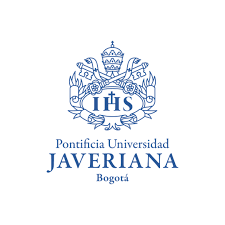
***Pontificia Universidad Javeriana***
# **Procesamiento de Alto Volumen de Datos**

### Taller: **Metricas y Machine Learning con PySpark**

Autor: Miguel Espinosa

Fecha: Mayo 25 2026


## **Objetivo**
- Cargar sesion spark
- cargar datos de banca
- entender los datos
- limpiar los datos

### **Caso de estudio:** Modelo de Comportamiento de Clientes para Depósito a Plazo Fijo en el Banco

#### Pasos a seguir:
- **1.- Importación de Bibliotecas y Sesión Spark**
- **2.- Hadoop HDFS: carga de ficheros de banca**
- **3.- Descripción y análisis del Dataset**
- **4.- Verificación de la calidad de los Datos**
- **5.- Preparación de los Datos**
- **6.- Limpieza de los Datos**
- **7.- Formato de los Datos**
- **8.- Codificación para la creación de vector ensamblador para las variables categóricas ("features", "target")**
- **9.- Modelización: construcción de modelos**
- **10.- Evaluación de los Modelos**
- **11.- Conclusiones**


## 1. importacion de Bibliotecas y sesión Spark

In [1]:
## Importar bibliotecas generales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from pylab import *
import findspark
findspark.init()
import pyspark.sql.functions as F
from pyspark import SparkConf, SparkContext
from pyspark.sql import SQLContext
from pyspark.sql import SparkSession
from pyspark.sql.types import *
from pyspark.ml.feature import StringIndexer,OneHotEncoder
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.ml import Pipeline
from sklearn.metrics import roc_curve, auc


In [2]:
### Levantamiento de sesión SPARK
configura = SparkConf()

configura.setAppName("Banca_Espinosa_Spark")

sparkEspinosa = SparkSession.builder.config(conf=configura).getOrCreate()

SQLContext(sparkContext=sparkEspinosa.sparkContext, sparkSession=sparkEspinosa)

sparkContextoS = sparkEspinosa.sparkContext.getOrCreate()

print("Sesion creada: ProcesamientoDatos04")

sparkEspinosa

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/25 22:14:09 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Sesion creada: ProcesamientoDatos04


## 2. Carga de Archivos

In [3]:
### Importar el Dataset
ex00 = pd.read_csv("bank-full.csv", sep=";")
df00 = sparkEspinosa.createDataFrame(ex00)
df00.show(5)

+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
|age|         job|marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
| 58|  management|married| tertiary|     no|   2143|    yes|  no|unknown|  5|  may|     261|       1|   -1|       0| unknown| no|
| 44|  technician| single|secondary|     no|     29|    yes|  no|unknown|  5|  may|     151|       1|   -1|       0| unknown| no|
| 33|entrepreneur|married|secondary|     no|      2|    yes| yes|unknown|  5|  may|      76|       1|   -1|       0| unknown| no|
| 47| blue-collar|married|  unknown|     no|   1506|    yes|  no|unknown|  5|  may|      92|       1|   -1|       0| unknown| no|
| 33|     unknown| single|  unknown|     no|      1|     no|  no|unknown|  5|  may|     19

In [4]:
#Conocer los datos antes de los cambios
df00.printSchema()

root
 |-- age: long (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: long (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: long (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: long (nullable = true)
 |-- campaign: long (nullable = true)
 |-- pdays: long (nullable = true)
 |-- previous: long (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)



## Comentarios
- Todos los datos se encuentran en tipo string
- Se identifica el cambio a entero o double
- Se observa que la ultima columna es la columna ETIQUETA


# 3. Detalles completos Dataset



## 🧾 Tabla de Variables

| Variable | Rol | Tipo | Demográfico | Descripción | Unidad | Valores Faltantes |
|:--|:--|:--|:--|:--|:--|:--|
| `age` | Feature | Integer | Edad | Edad del cliente | Años |  No |
| `job` | Feature | Categorical | Ocupación | Tipo de trabajo (`admin.`, `blue-collar`, `entrepreneur`, etc.) | — | ❌ No |
| `marital` | Feature | Categorical | Estado civil | Estado civil del cliente (`divorced`, `married`, `single`, `unknown`) | — | ❌ No |
| `education` | Feature | Categorical | Nivel educativo | Nivel de educación (`basic.4y`, `high.school`, `university.degree`, etc.) | — | ❌ No |
| `default` | Feature | Binary | — | ¿Tiene crédito en incumplimiento? | Sí / No | ❌ No |
| `balance` | Feature | Integer | — | Balance promedio anual | Euros (€) | ❌ No |
| `housing` | Feature | Binary | — | ¿Tiene préstamo hipotecario? | Sí / No | ❌ No |
| `loan` | Feature | Binary | — | ¿Tiene préstamo personal? | Sí / No | ❌ No |
| `contact` | Feature | Categorical | — | Tipo de contacto (`cellular`, `telephone`) | — | ⚠️ Sí |
| `day_of_week` | Feature | Date | — | Último día de contacto de la semana | Día | ❌ No |
| `month` | Feature | Date | — | Último mes de contacto (`jan`, `feb`, ..., `dec`) | Mes | ❌ No |
| `duration` | Feature | Integer | — | Duración de la última llamada en segundos. ⚠️ Puede generar *data leakage* en modelos predictivos realistas. | Segundos | ❌ No |
| `campaign` | Feature | Integer | — | Número de contactos realizados durante esta campaña | Conteo | ❌ No |
| `pdays` | Feature | Integer | — | Días transcurridos desde el último contacto de una campaña previa (`-1` = no contactado previamente) | Días | ⚠️ Sí |
| `previous` | Feature | Integer | — | Número de contactos realizados antes de esta campaña | Conteo | ❌ No |
| `poutcome` | Feature | Categorical | — | Resultado de la campaña de marketing anterior (`failure`, `nonexistent`, `success`) | — | ⚠️ Sí |
| `y` | Target | Binary | — | ¿El cliente suscribió un depósito a plazo fijo? | Sí / No | ❌ No |

---

In [5]:
#cantidad de datos
print(f"Se tiene un total de {df00.count()} registros")

[Stage 1:===================>                                       (2 + 4) / 6]

Se tiene un total de 45211 registros


In [6]:
#Se presenta las estadísticas de los datos a continuación:

for valor in df00.columns:
  
  df00.describe([valor]).show()

+-------+------------------+
|summary|               age|
+-------+------------------+
|  count|             45211|
|   mean| 40.93621021432837|
| stddev|10.618762040975408|
|    min|                18|
|    max|                95|
+-------+------------------+



+-------+-------+
|summary|    job|
+-------+-------+
|  count|  45211|
|   mean|   NULL|
| stddev|   NULL|
|    min| admin.|
|    max|unknown|
+-------+-------+

+-------+--------+
|summary| marital|
+-------+--------+
|  count|   45211|
|   mean|    NULL|
| stddev|    NULL|
|    min|divorced|
|    max|  single|
+-------+--------+

+-------+---------+
|summary|education|
+-------+---------+
|  count|    45211|
|   mean|     NULL|
| stddev|     NULL|
|    min|  primary|
|    max|  unknown|
+-------+---------+

+-------+-------+
|summary|default|
+-------+-------+
|  count|  45211|
|   mean|   NULL|
| stddev|   NULL|
|    min|     no|
|    max|    yes|
+-------+-------+

+-------+------------------+
|summary|           balance|
+-------+------------------+
|  count|             45211|
|   mean|1362.2720576850766|
| stddev| 3044.765829168519|
|    min|             -8019|
|    max|            102127|
+-------+------------------+

+-------+-------+
|summary|housing|
+-------+-------+
|  co

In [7]:
## nombre de las columnas
df00.columns

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'y']

In [8]:
#las siguientes columnas se cambian a INT
colInt = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
df01 = df00
df01 = df01.withColumn('age', df01.age.cast("int")) 
df01 = df01.withColumn('balance', df01.balance.cast("int")) 
df01 = df01.withColumn('day', df01.day.cast("int")) 
df01 = df01.withColumn('duration', df01.duration.cast("int")) 
df01 = df01.withColumn('campaign', df01.campaign.cast("int")) 
df01 = df01.withColumn('pdays', df01.pdays.cast("int")) 
df01 = df01.withColumn('previous', df01.previous.cast("int")) 

df01.printSchema()

root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- pdays: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)



In [9]:
#Se revisa el balance del dataset. La idea es conocer si hay posibilidades de SESGO
total = df01.count()
df_Y = df01.groupBy("y").count()

auxPD = df_Y.withColumn("Porcentaje", df_Y["count"]*100/total)

auxPD.show()

+---+-----+------------------+
|  y|count|        Porcentaje|
+---+-----+------------------+
| no|39922| 88.30151954170445|
|yes| 5289|11.698480458295547|
+---+-----+------------------+



## Comentarios
    - Al observar el balanceo sobre las etiquetas o la columna target se observa:
        - La clase minoritaria es "yes" con un 11.7% representa 5289 registros
        - La clase Mayoritaria es "no" con un 8.3% representa 39922 registros
    - La variable es binariay es importante tener en cuenta no hacer sesgo al tratar los modelos para hacer la prediccion
    -se recomienda revisar de forma exhaustiva las estadisticas completas del dataset



In [10]:
#se revisa de forma exhaustiva las estadisticas completas del dataset
df01.describe().toPandas()

26/05/25 22:14:48 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

,summary,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
1,mean,40.93621021432837,None,None,None,None,1362.2720576850766,None,None,None,15.80641879188693,None,258.1630797814691,2.763840658246887,40.19782796222158,0.5803233726305546,None,None
2,stddev,10.618762040975406,None,None,None,None,3044.765829168519,None,None,None,8.322476153044589,None,257.527812265172,3.0980208832791654,100.12874599059843,2.3034410449312195,None,None
3,min,18,admin.,divorced,primary,no,-8019,no,no,cellular,1,apr,0,1,-1,0,failure,no
4,max,95,unknown,single,unknown,yes,102127,yes,yes,unknown,31,sep,4918,63,871,275,unknown,yes


## Comentarios:
- se observa las estadisticas de los valores nominales
- Se puede havcer las presentaciones convertidas en objetos PANDAS, siempre que sean DF pequeños consumen mucha memoria

- En relacion a la edad:
      - Se puede observar que las personas se encuentran entre 18 y 95 años
      - El promedio de edad esta en 40 años aproximadamente
      -La variacion es de 10 años al rededor de 40 años

- En relacion al trabajo: 
    - La categoria administrador es la que menos aparece
    - La categoria unknown es la que mas aparece, la mayor parte de los registros se desonoce en que trabaja
    

- En relacion a la variable duration (tiempo de llamadas en segundos):
    -Se observa que el promedio de duracion de llamadas es 258s aproximadamente
    -La dispersion de 257 segundos
    -Esto refleja que el tiempo promedio y la desviacion al ser similares...

- En relacion  a la variable contact (Cantidad de veces que contactan al cliente en una "campaign")
    -Se observa que el promedio es aproximadamente de 2.76
    -La dispersion de...
    -Esto refleja que...

  - En relacion  a la variable contact (Cantidad de veces que contactan al cliente en una "campaign")
    -Se observa que el promedio es aproximadamente de 1362 euros
    -La dispersion de...
    -Esto refleja que...

## Se requiere observar en detalle las variables categoricas
- Se agrupa cada categoria y se cuenta el numero de ocurrencias en cada grupo

In [11]:
### Seleccionar solo las variables categoricas
col_cat = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']

### Se agrupa y se observa cada categoria
for col in col_cat:
    df01.groupBy(col).count().show()

+-------------+-----+
|          job|count|
+-------------+-----+
|   management| 9458|
|      retired| 2264|
|      unknown|  288|
|self-employed| 1579|
|      student|  938|
|  blue-collar| 9732|
| entrepreneur| 1487|
|       admin.| 5171|
|   technician| 7597|
|     services| 4154|
|    housemaid| 1240|
|   unemployed| 1303|
+-------------+-----+

+--------+-----+
| marital|count|
+--------+-----+
|divorced| 5207|
| married|27214|
|  single|12790|
+--------+-----+

+---------+-----+
|education|count|
+---------+-----+
|  unknown| 1857|
| tertiary|13301|
|secondary|23202|
|  primary| 6851|
+---------+-----+

+-------+-----+
|default|count|
+-------+-----+
|     no|44396|
|    yes|  815|
+-------+-----+

+-------+-----+
|housing|count|
+-------+-----+
|     no|20081|
|    yes|25130|
+-------+-----+

+----+-----+
|loan|count|
+----+-----+
|  no|37967|
| yes| 7244|
+----+-----+

+---------+-----+
|  contact|count|
+---------+-----+
|  unknown|13020|
| cellular|29285|
|telephone| 2906|
+

### Se requiere observar en graficas las variables numericas
- Se agrupa cada variable numerica y se grafica el numero de ocurrencias en cada grupo

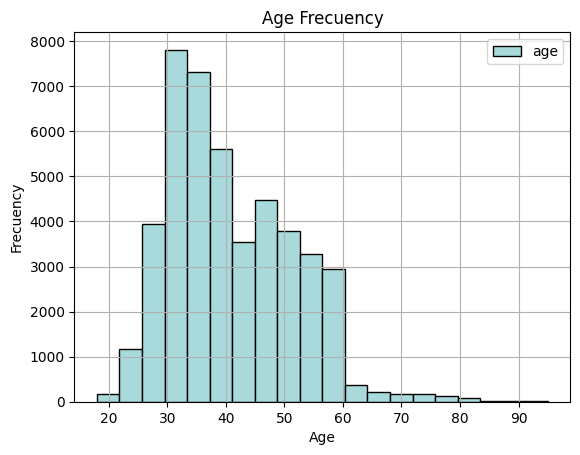

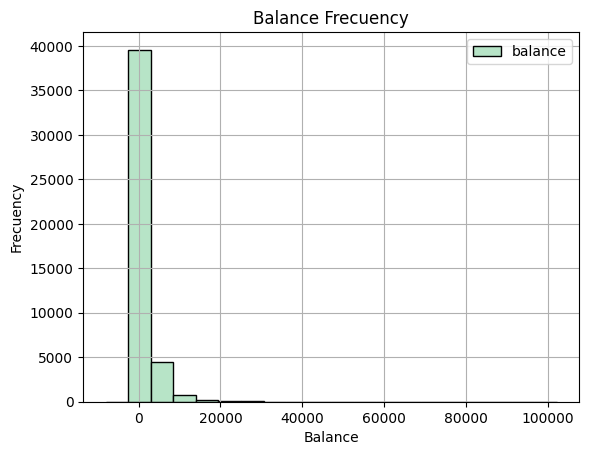

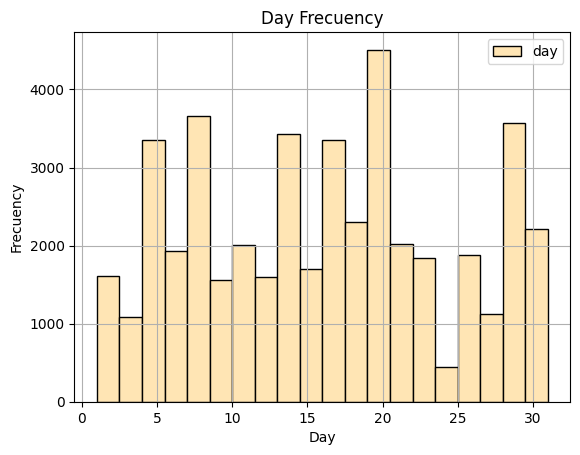

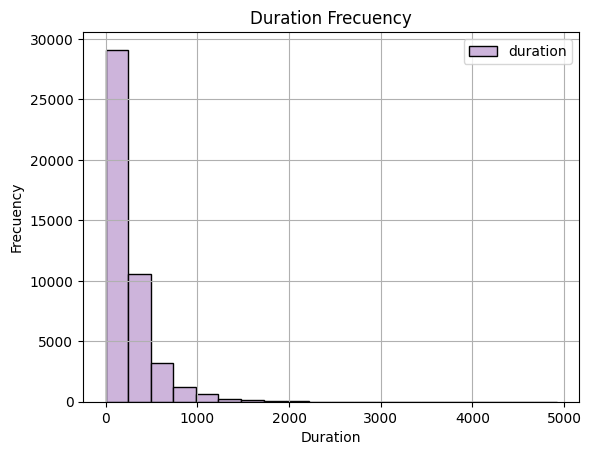

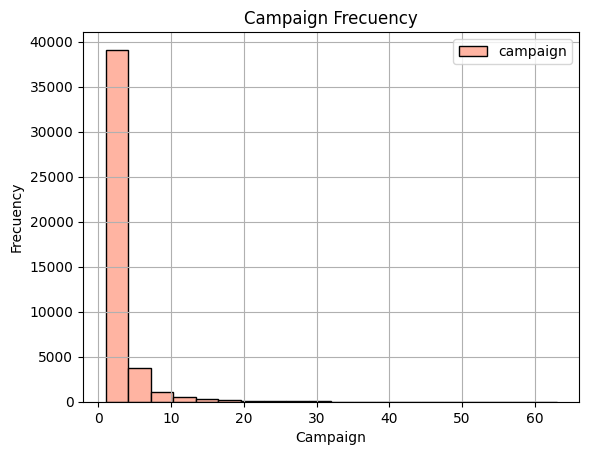

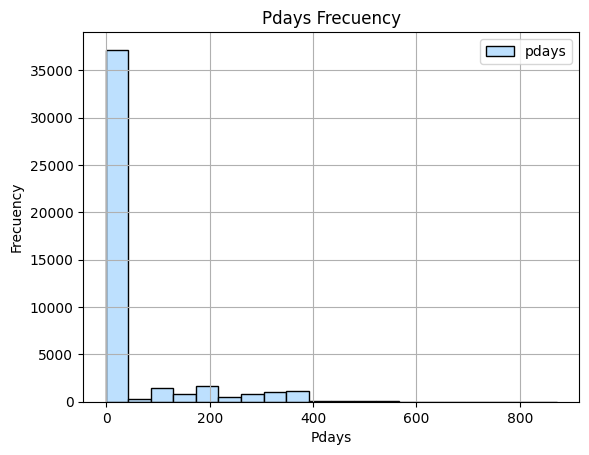

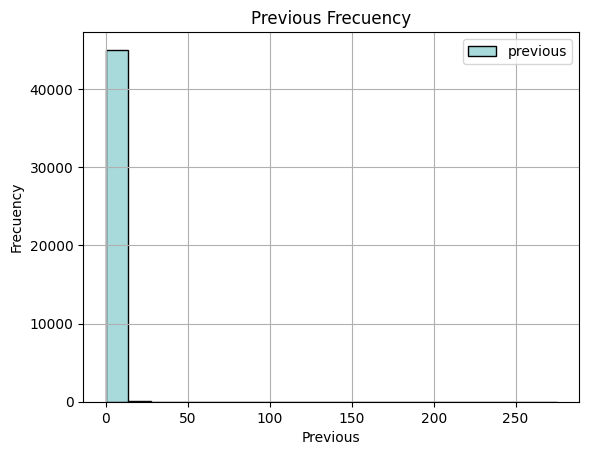

In [12]:
coloresPasteles = ['#A8DADC', '#B7E4C7', '#FFE5B4', '#CDB4DB', '#FFB4A2', '#BDE0FE']
for i, col_int in enumerate(colInt):
    histGra = df01.select(col_int).toPandas()
    histGra.plot(kind='hist', bins=20, edgecolor='black', color=coloresPasteles[i % len(coloresPasteles)])
    plt.ylabel("Frecuency")
    plt.xlabel(col_int.capitalize())
    plt.title(f"{col_int.capitalize()} Frecuency")
    plt.grid()
    plt.show()

### Comentarios generales de las gráficas:

#### Age Frequency

- La variable age presenta una mayor concentración de clientes entre los 30 y 40 años aproximadamente. Después de los 60 años, la frecuencia disminuye considerablemente, lo que indica que la mayoría de los registros pertenecen a personas en edad laboral activa.

#### Balance Frequency

- La variable balance muestra una distribución muy concentrada cerca de valores bajos, principalmente alrededor de 0. También se observan valores muy altos alejados de la mayoría de datos, lo que sugiere la presencia de posibles valores atípicos o clientes con saldos significativamente superiores al promedio.

#### Day Frequency

- La variable day presenta una distribución más variada a lo largo del mes. Se observan algunos días con mayor frecuencia, especialmente alrededor del día 20, lo que puede indicar que las campañas o contactos bancarios no se distribuyeron de manera completamente uniforme durante el mes.

#### Duration Frequency

- La variable duration tiene una distribución sesgada hacia la derecha, donde la mayoría de llamadas tienen una duración baja y pocas llamadas alcanzan valores muy altos. Esto indica que la mayoría de los contactos fueron relativamente cortos, aunque existen algunos casos con duraciones mucho más extensas.

#### Campaign Frequency

- La variable campaign muestra que la mayoría de clientes fueron contactados pocas veces durante la campaña. A medida que aumenta el número de contactos, la frecuencia disminuye rápidamente, lo cual evidencia que pocos clientes recibieron una cantidad elevada de intentos de contacto.

#### Pdays Frequency

- La variable pdays se concentra fuertemente en valores bajos, especialmente cerca de 0. Esto indica que para una gran cantidad de clientes no hubo un contacto previo reciente o que el tiempo desde el último contacto fue muy bajo en comparación con el resto de valores.

#### Previous Frequency

- La variable previous presenta una concentración muy marcada en valores cercanos a 0. Esto indica que la mayoría de los clientes no habían sido contactados muchas veces en campañas anteriores, mientras que los valores altos son poco frecuentes y pueden considerarse casos aislados.

## Se requiere analizar a fondo las variables numericas
- Se agrupa cada variable numerica y se grafica con el tpo de grafica boxplot
- Las graficas boxplot son...

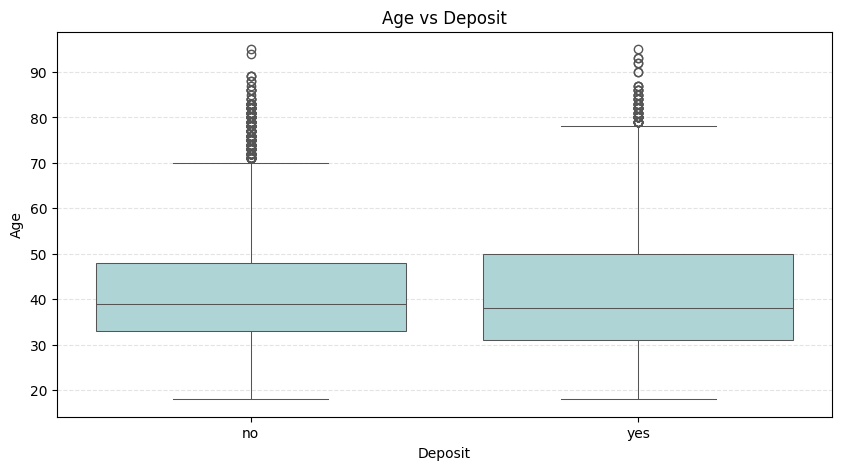

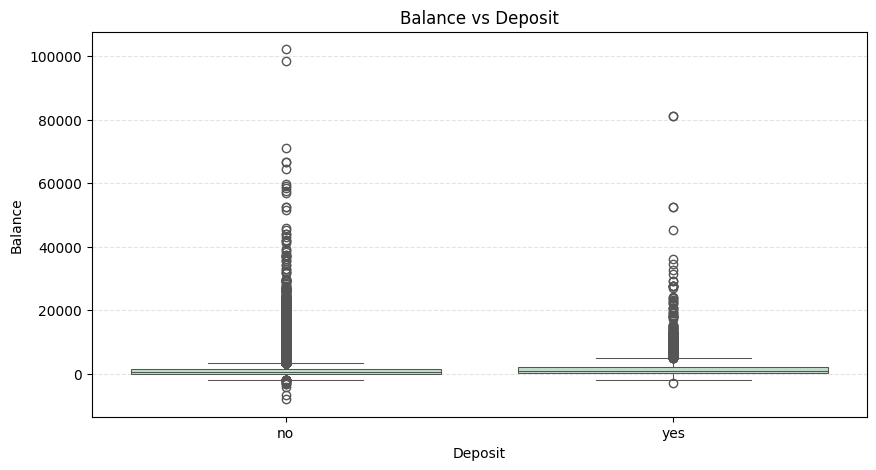

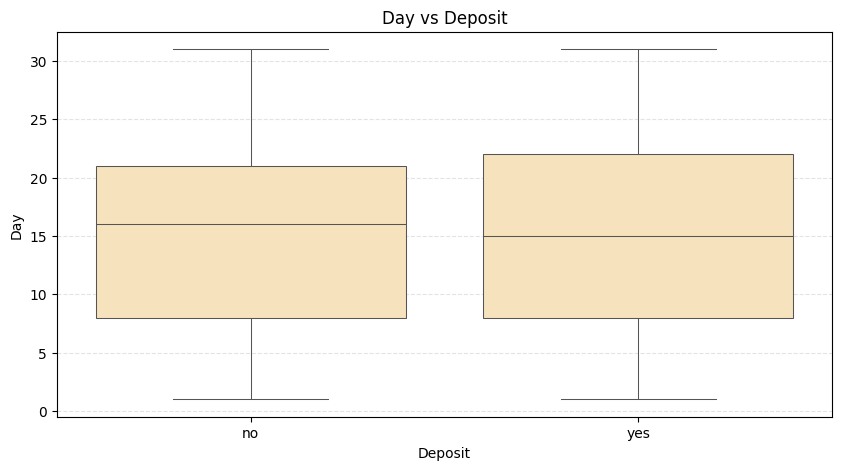

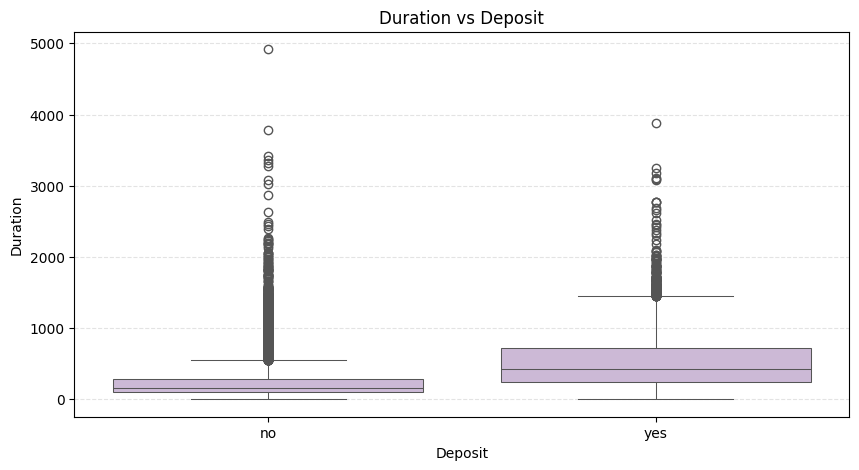

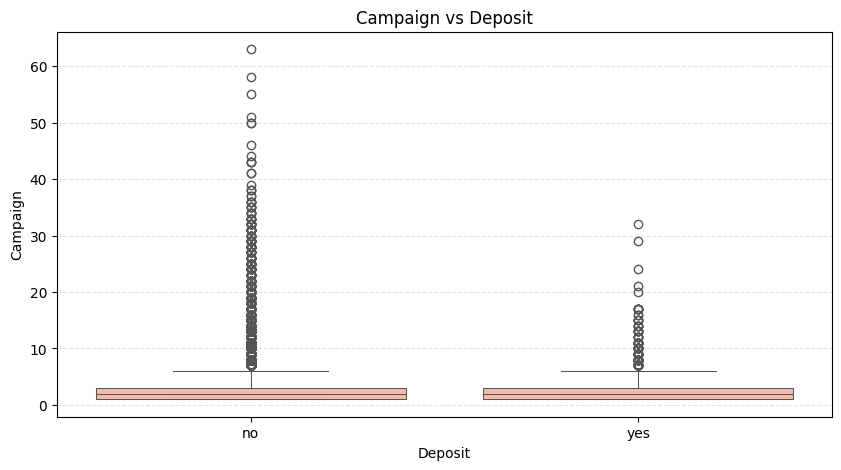

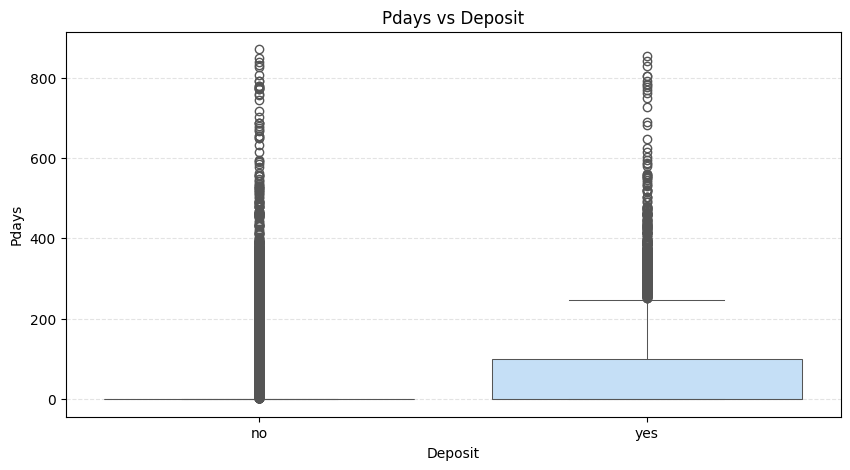

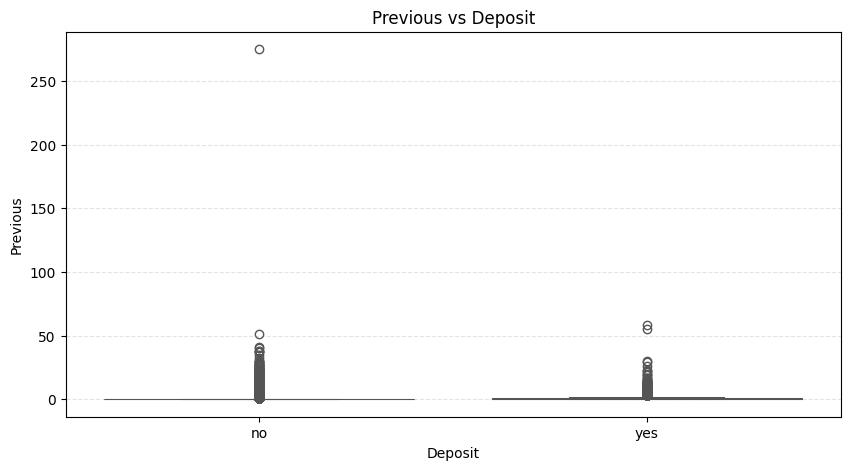

In [13]:
coloresPasteles = ['#A8DADC', '#B7E4C7', '#FFE5B4', '#CDB4DB', '#FFB4A2', '#BDE0FE']
for i, col_int in enumerate(colInt):
    plt.figure(figsize=(10,5))
    sns.boxplot( x='y', y=col_int, data=df01.toPandas(), color=coloresPasteles[i % len(coloresPasteles)], linecolor="#555555", linewidth=0.75)
    plt.title(f"{col_int.capitalize()} vs Deposit")
    plt.xlabel("Deposit")
    plt.ylabel(col_int.capitalize())
    plt.grid(axis='y', linestyle='--', alpha=0.35)
    plt.show()

### Comentarios generales de las gráficas:

#### Age vs Deposit

- La variable age muestra distribuciones similares entre los clientes que aceptaron y no aceptaron el depósito. Sin embargo, en la categoría yes se observa una dispersión ligeramente mayor, lo que indica que los clientes que aceptan pueden pertenecer a rangos de edad más variados.

- La mediana de edad es cercana en ambas clases, aproximadamente entre los 35 y 40 años. Esto sugiere que la edad por sí sola no parece ser una variable completamente determinante para explicar la aceptación del depósito.

- Se observan varios valores atípicos en edades superiores a los 70 años, tanto para yes como para no. Esto indica que existen clientes mayores dentro del conjunto de datos, aunque representan una proporción menor frente al grupo principal.

#### Balance vs Deposit

- La variable balance presenta una fuerte concentración de valores cercanos a cero en ambas clases. Esto indica que la mayoría de clientes tienen saldos relativamente bajos o moderados.

- Se observan muchos valores atípicos altos, especialmente en la categoría no, donde algunos clientes alcanzan balances cercanos o superiores a 100000. Esto muestra que existen clientes con saldos muy elevados, pero no necesariamente asociados con la aceptación del depósito.

- Aunque los clientes con yes parecen tener una ligera tendencia a balances positivos, la diferencia visual no es lo suficientemente fuerte como para afirmar que el balance por sí solo explica la decisión del cliente.

#### Day vs Deposit

- La variable day presenta una distribución bastante parecida entre las categorías yes y no. Esto indica que el día del mes en que se realizó el contacto no parece generar una diferencia marcada en la aceptación del depósito.

- Las medianas de ambas clases son cercanas, alrededor de la mitad del mes. Esto sugiere que los contactos se distribuyeron de forma relativamente equilibrada entre los diferentes días.

- Aunque existen pequeñas diferencias en la amplitud de los rangos, la variable day no parece tener una separación clara entre clientes que aceptan y clientes que no aceptan.

#### Duration vs Deposit

- La variable duration muestra una diferencia importante entre las clases. Los clientes que aceptaron el depósito presentan una mediana de duración más alta que los clientes que no aceptaron.

- Esto sugiere que las llamadas más largas están más relacionadas con una respuesta positiva del cliente. Por lo tanto, duration parece ser una de las variables numéricas con mayor capacidad explicativa dentro del análisis.

- También se observan muchos valores atípicos en ambas clases, especialmente en llamadas de larga duración. Sin embargo, la categoría yes presenta una distribución más elevada, lo que refuerza su relación con la aceptación del depósito.

#### Campaign vs Deposit

- La variable campaign muestra que la mayoría de clientes fueron contactados pocas veces, tanto en yes como en no. Esto indica que la mayor parte de la campaña se concentró en pocos intentos de contacto por cliente.

- En la categoría no se observan más valores atípicos altos, lo que sugiere que insistir muchas veces en contactar a un cliente no necesariamente aumenta la probabilidad de aceptación.

- La distribución muestra que los clientes que aceptaron el depósito tienden a concentrarse en valores bajos de campaign. Esto puede indicar que un número excesivo de contactos podría estar asociado con menor efectividad.

#### Pdays vs Deposit

- La variable pdays presenta una diferencia visible entre las clases. En la categoría no, la mayoría de valores se concentran cerca de cero, mientras que en la categoría yes se observa una mayor dispersión.

- Esto puede indicar que los clientes que aceptaron el depósito tuvieron, en algunos casos, una relación previa más relevante con campañas anteriores o un intervalo distinto desde el último contacto.

- La presencia de muchos valores atípicos muestra que esta variable tiene una distribución irregular. Aun así, parece aportar información útil para diferenciar parcialmente entre clientes que aceptan y clientes que no aceptan.

#### Previous vs Deposit

- La variable previous se concentra principalmente en valores bajos para ambas clases. Esto indica que la mayoría de clientes tenían pocos o ningún contacto previo antes de esta campaña.

- Se observan valores atípicos en ambas categorías, aunque en no aparece un caso extremadamente alto. Esto puede representar un cliente con una cantidad inusual de contactos previos, por lo que debería revisarse como posible valor atípico.

- Aunque la variable previous no muestra una separación muy fuerte entre yes y no, sí puede aportar información complementaria cuando se combina con otras variables como pdays, campaign y duration.

### Entendimiento de  los datos numericos: Matriz de correlacion
- se requiere hacer un objeto datafreame auxiliar con solo las columnas numericas
- La variable "y" o variable independiente, se requiere pasar 'yes' == 1

In [14]:
colNum = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
### Se requiere  cambiar la columna "y" de si o no a 1 y 0
### adicional se requiere incorporarla al dataframe numerico 

dfauxNum = df01.select(colNum + ['y'])
dfauxNum = dfauxNum.withColumn('y', F.when(dfauxNum['y'] == 'yes', 1).otherwise(0))
dfauxNum.show(5)

+---+-------+---+--------+--------+-----+--------+---+
|age|balance|day|duration|campaign|pdays|previous|  y|
+---+-------+---+--------+--------+-----+--------+---+
| 58|   2143|  5|     261|       1|   -1|       0|  0|
| 44|     29|  5|     151|       1|   -1|       0|  0|
| 33|      2|  5|      76|       1|   -1|       0|  0|
| 47|   1506|  5|      92|       1|   -1|       0|  0|
| 33|      1|  5|     198|       1|   -1|       0|  0|
+---+-------+---+--------+--------+-----+--------+---+
only showing top 5 rows



In [15]:
### El anterior dataframe auxiliar se convierte en un VectorAssembler de 'feature'
### (fijate que se incorpora la variable "y" con los numericos para hacer el vector)
### La idea es que con el vector se pueda representar escalada/normalizada la matriz de correlacion

from pyspark.ml.feature import OneHotEncoder, StringIndexer, VectorAssembler
from pyspark.ml.stat import Correlation
ensamblador = VectorAssembler(inputCols=dfauxNum.columns, outputCol='features')
#Normalizado y escalado
dfNumVector = ensamblador.transform(dfauxNum).select('features')

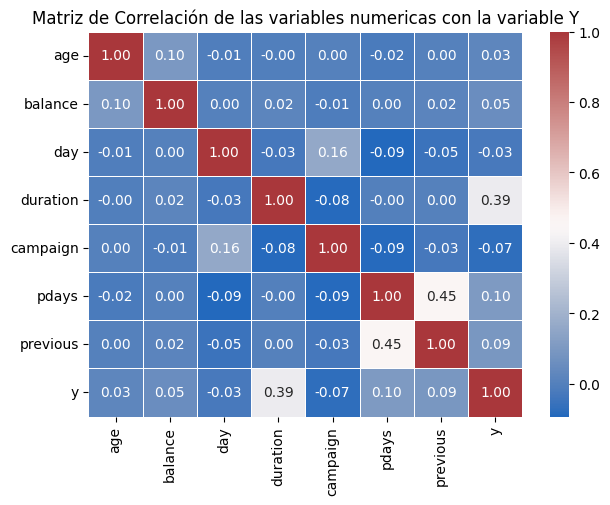

In [16]:
### Se grafica la matriz de corelacion: se tiene en cuenta que los datos son ensamblados
matrizCorr = Correlation.corr(dfNumVector, 'features').head()

# se procede a pintar la matriz de correlacion
vectorCorr = matrizCorr[0].toArray()

#Se crea un objeto dataframe con el vector anterior de Correlacion de Pearson
dfCorrelatio = pd.DataFrame(vectorCorr, columns= dfauxNum.columns, index=dfauxNum.columns)
# Se crea una paleta de colores pasteles para la matriz de correlacion
cmapJOHN = "vlag"
plt.figure(figsize=(7,5))
sns.heatmap(dfCorrelatio, annot=True, cmap=cmapJOHN, linewidths=0.5, linecolor='white', fmt=".2f")

plt.title("Matriz de Correlación de las variables numericas con la variable Y")
plt.show()

### Comentarios generales:

- La variable duration presenta la correlación más alta con la variable dependiente y, con un valor aproximado de 0.39, se posiciona como la variable numérica más relacionada con la aceptación del depósito. Esto coincide con el análisis previo, donde las llamadas más largas se asociaban con una mayor probabilidad de respuesta positiva.

- La mayoría de variables numéricas tienen correlaciones bajas con y, como age, balance, day, campaign y previous. Esto indica que, de forma individual, estas variables no explican con mucha fuerza la decisión del cliente, aunque pueden aportar información útil cuando se combinan dentro de los modelos.


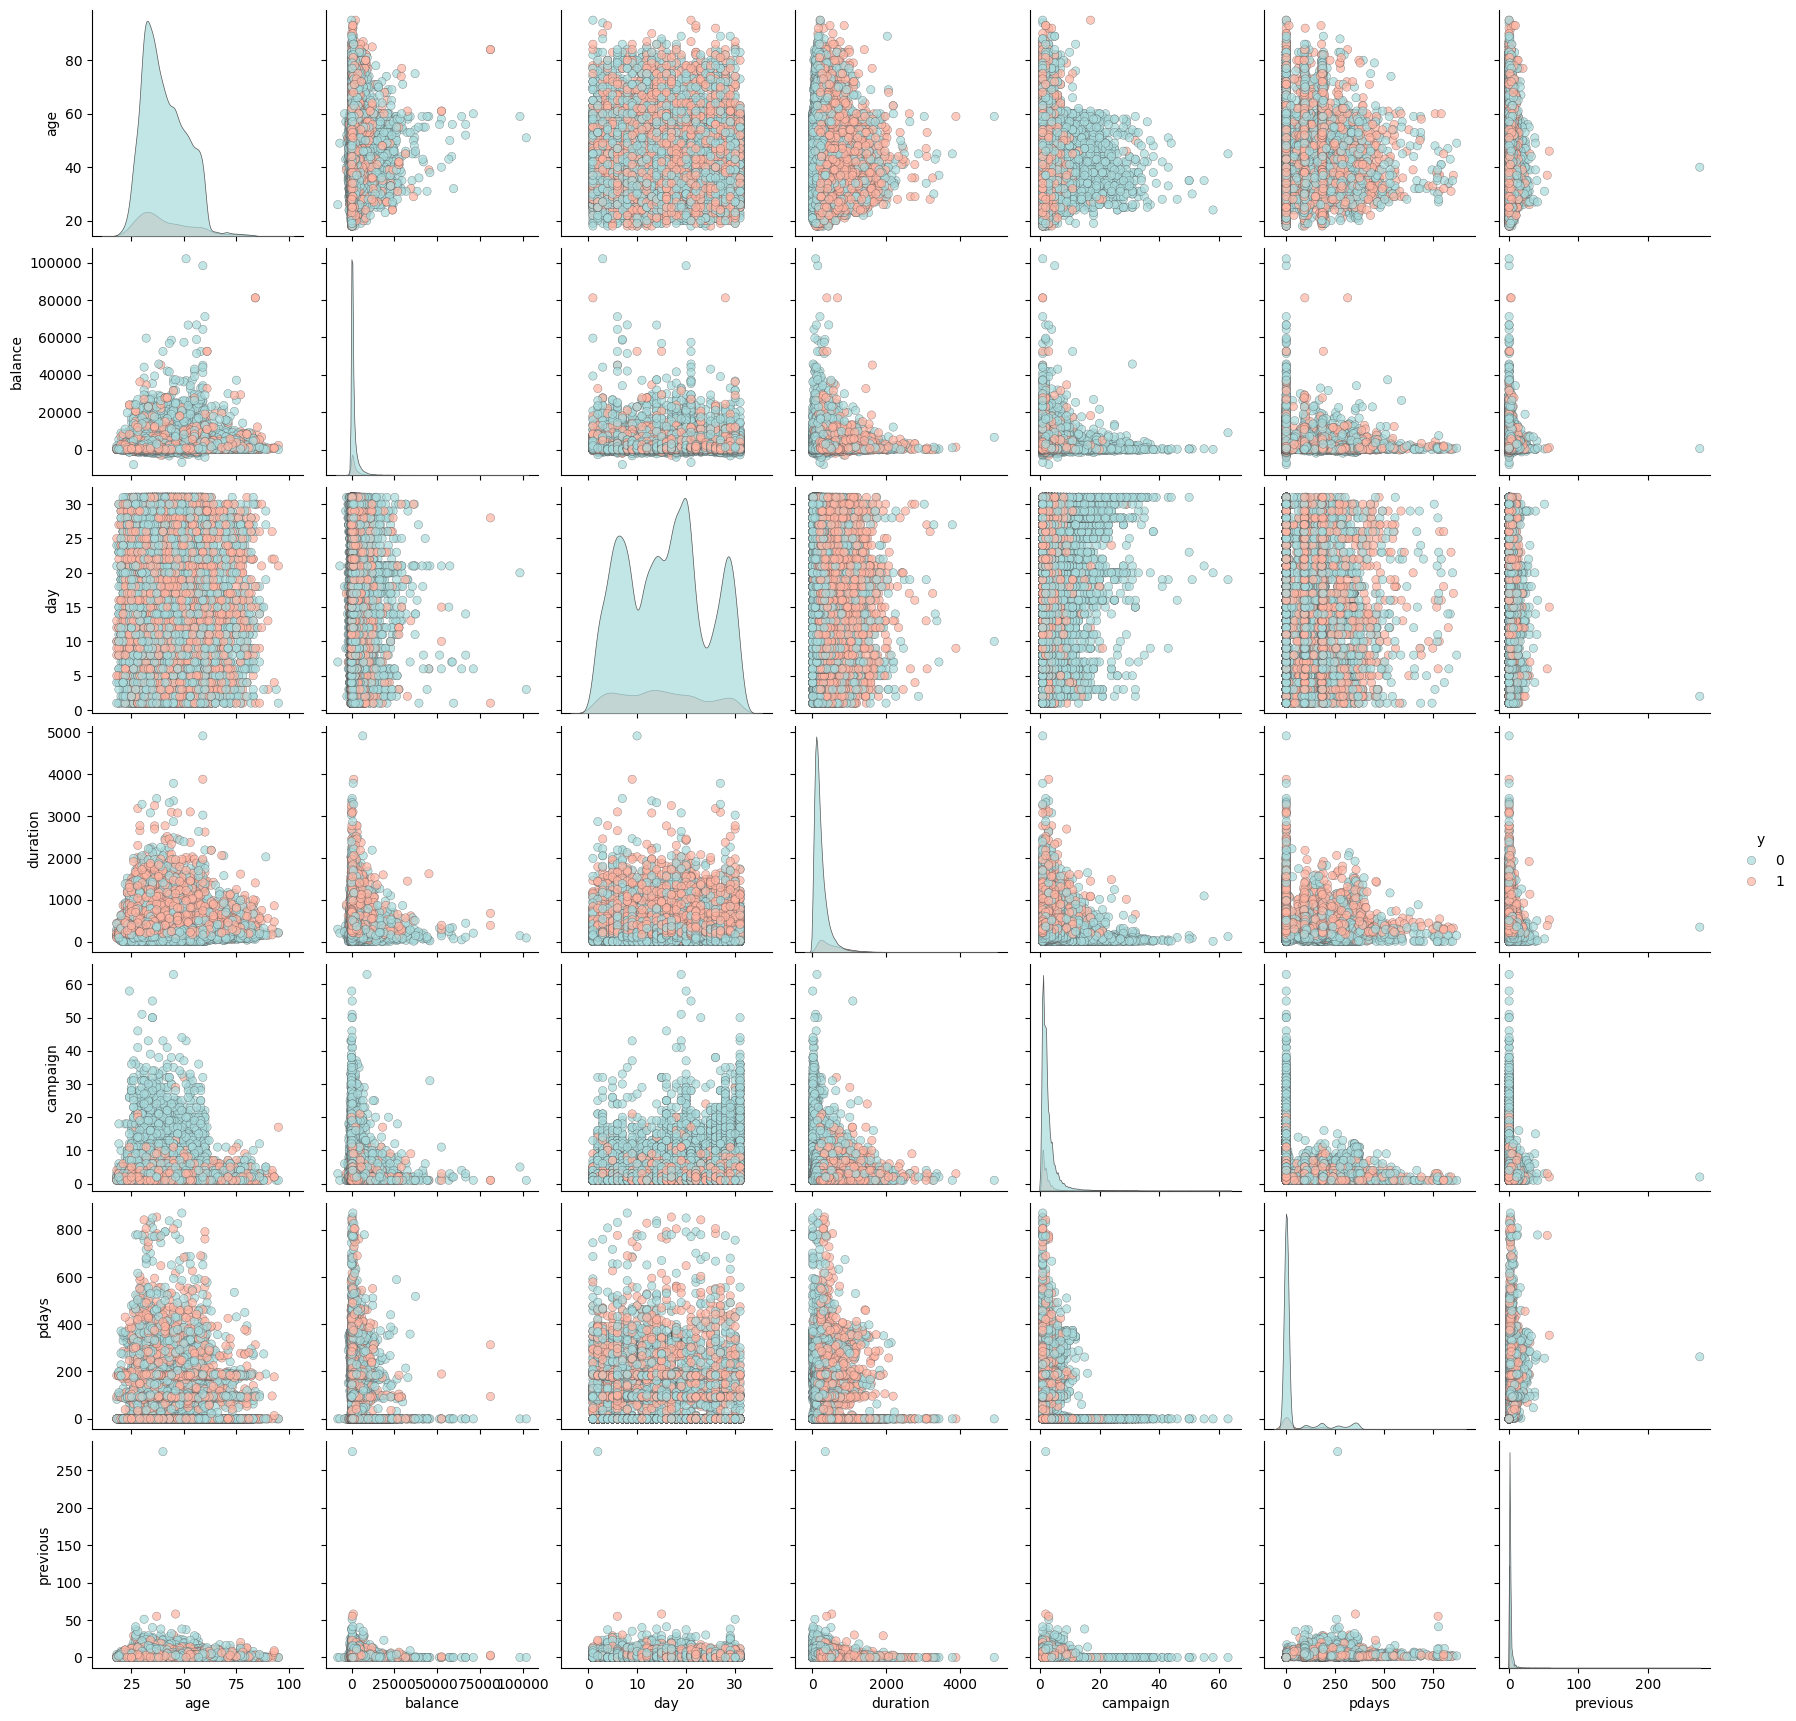

In [106]:
## Se requiere hacer un grafico sobre todas las variables
coloresPasteles = ['#A8DADC', '#FFB4A2']
sns.pairplot( dfauxNum.toPandas(), kind='scatter', hue='y', palette=coloresPasteles, plot_kws={'alpha': 0.7, 'edgecolor': '#555555', 'linewidth': 0.3}, diag_kws={'alpha': 0.7, 'edgecolor': '#555555', 'linewidth': 0.5})
plt.show()

### Comentarios generales:

- En la mayoría de relaciones entre variables numéricas no se observa una separación completamente clara entre las clases de la variable dependiente. Los puntos de ambas categorías se mezclan en gran parte de las gráficas, lo que indica que una sola variable numérica no es suficiente para explicar por completo el comportamiento de la variable dependiente.

- La variable duration parece ser una de las más relevantes frente a la variable dependiente, ya que se observa una mayor presencia de registros de la clase 1 en llamadas con mayor duración. Esto sugiere que las llamadas más largas pueden estar asociadas con una mayor probabilidad de aceptación del depósito.

- Las variables balance, campaign, pdays y previous presentan distribuciones muy sesgadas y con varios valores atípicos. Esto confirma que existen clientes con comportamientos extremos, por lo que estas variables deben analizarse con cuidado para evitar que afecten demasiado el entrenamiento de los modelos.

- La variable campaign muestra que la mayoría de los clientes fueron contactados pocas veces, mientras que los contactos muy altos son poco frecuentes. Esto puede indicar que una mayor cantidad de intentos de contacto no necesariamente mejora la respuesta positiva de la variable dependiente.

- En general, las gráficas muestran que las relaciones entre variables no son lineales ni simples. Por esta razón, modelos más robustos como Random Forest o Gradient Boosted Tree pueden ser más adecuados, ya que tienen mayor capacidad para capturar patrones combinados entre variables.

## Grafico de torta para variables yes no
- default
- loan
- housing

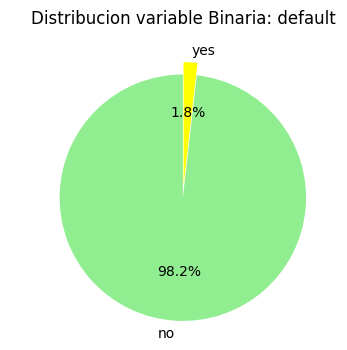

In [18]:
### se requiere pintar default, housing, loan por separado
## de esa manera se hace puntial el analisis
explode = (0.1, 0) #"explode" the first slice
colors= ['lightgreen', 'yellow'] #array of custom colors


plt.figure(figsize=(5,4))
cantBin = df01.groupBy('default').count().toPandas()
cantBin.set_index('default')['count'].plot(kind = 'pie', explode=explode, colors=colors, autopct= '%1.1f%%', startangle =90)
plt.title(f'Distribucion variable Binaria: default')
plt.ylabel(' ')
plt.show()
plt.show()

### Comentarios default

- En la variable default se observa que la gran mayoría de los clientes no presenta incumplimiento crediticio, con un 98.2% en la categoría no. Esto indica que esta variable está fuertemente desbalanceada.

- Solo el 1.8% de los registros pertenece a la categoría yes, por lo que default puede aportar poca variabilidad por sí sola. Sin embargo, sigue siendo una variable relevante porque permite identificar un grupo pequeño de clientes con posible mayor riesgo financiero.


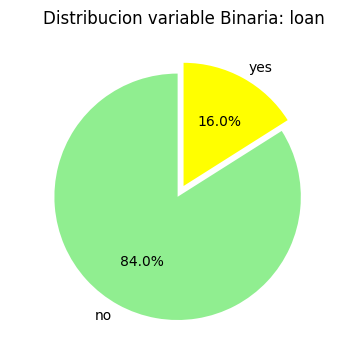

In [19]:
explode = (0.1, 0) #"explode" the first slice
colors= ['lightgreen', 'yellow'] #array of custom colors


plt.figure(figsize=(5,4))
cantBin = df01.groupBy('loan').count().toPandas()
cantBin.set_index('loan')['count'].plot(kind = 'pie', explode=explode, colors=colors, autopct= '%1.1f%%', startangle =90)
plt.title(f'Distribucion variable Binaria: loan')
plt.ylabel(' ')
plt.show()
plt.show()

### Comentarios loan

- En la variable loan se observa que el 84.0% de los clientes no tiene préstamo personal, mientras que el 16.0% sí lo tiene. Esto muestra una distribución desbalanceada, aunque menos extrema que en default.

- La mayoría de clientes no posee préstamo, lo cual puede ser relevante para analizar su disposición financiera frente a una campaña bancaria. Los clientes con loan en yes podrían tener un comportamiento diferente frente a la aceptación del depósito.


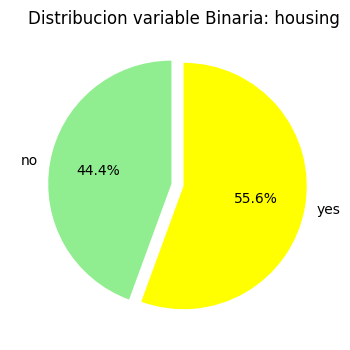

In [20]:
explode = (0.1, 0) #"explode" the first slice
colors= ['lightgreen', 'yellow'] #array of custom colors


plt.figure(figsize=(5,4))
cantBin = df01.groupBy('housing').count().toPandas()
cantBin.set_index('housing')['count'].plot(kind = 'pie', explode=explode, colors=colors, autopct= '%1.1f%%', startangle =90)
plt.title(f'Distribucion variable Binaria: housing')
plt.ylabel(' ')
plt.show()
plt.show()

### Comentarios housing

- En la variable housing se observa una distribución más equilibrada en comparación con default y loan. El 55.6% de los clientes tiene crédito de vivienda, mientras que el 44.4% no lo tiene.

- Esta variable puede ser importante para el modelo, ya que divide a los clientes en dos grupos con proporciones similares. Esto permite que housing tenga mayor capacidad de aportar información en la clasificación frente a otras variables binarias más desbalanceadas.

## Variables categoricas multidimensionales 

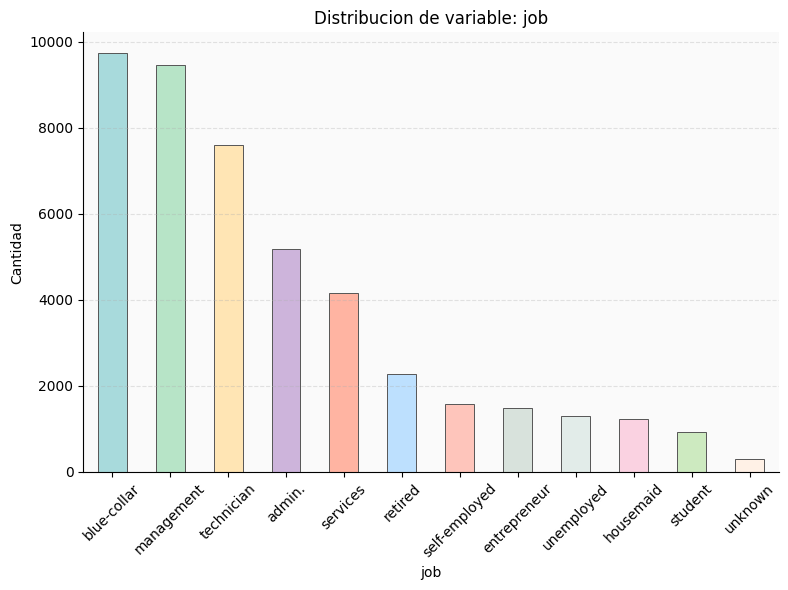

In [98]:
# las variables son: job, marital, education, contact, month, poutcome
canMulti = df01.groupBy('job').count().toPandas()
### se grafica en orden ascendente segun frecuencia
cantMulti= canMulti.sort_values('count', ascending=False)
plt.figure(figsize=(8,6))
coloresPasteles = ['#A8DADC', '#B7E4C7', '#FFE5B4', '#CDB4DB', '#FFB4A2', '#BDE0FE', '#FEC5BB', '#D8E2DC', '#E2ECE9', '#FAD2E1', '#CDEAC0', '#FFF1E6']
cantMulti.plot(kind='bar', x='job', y='count', legend=None, color=coloresPasteles[:len(cantMulti)], edgecolor='#555555', linewidth=0.7, ax=plt.gca())
plt.xlabel('job')
plt.ylabel('Cantidad')
plt.title(f'Distribucion de variable: job')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.35)
plt.gca().set_facecolor('#FAFAFA')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### Comentarios job

- En la variable job se observa que las categorías con mayor cantidad de registros son blue-collar, management y technician. Esto indica que una parte importante de los clientes del conjunto de datos pertenece a ocupaciones operativas, administrativas o técnicas.

- Las categorías con menor frecuencia son unknown, student, housemaid y unemployed. Estas clases tienen menos representación dentro del dataset, por lo que su aporte al modelo puede ser menor en comparación con las ocupaciones más frecuentes.

- La distribución de job no es uniforme, ya que existen diferencias claras entre las ocupaciones. Por esta razón, esta variable puede aportar información relevante al modelo, especialmente si algunos perfiles laborales presentan mayor tendencia a aceptar o rechazar el depósito.

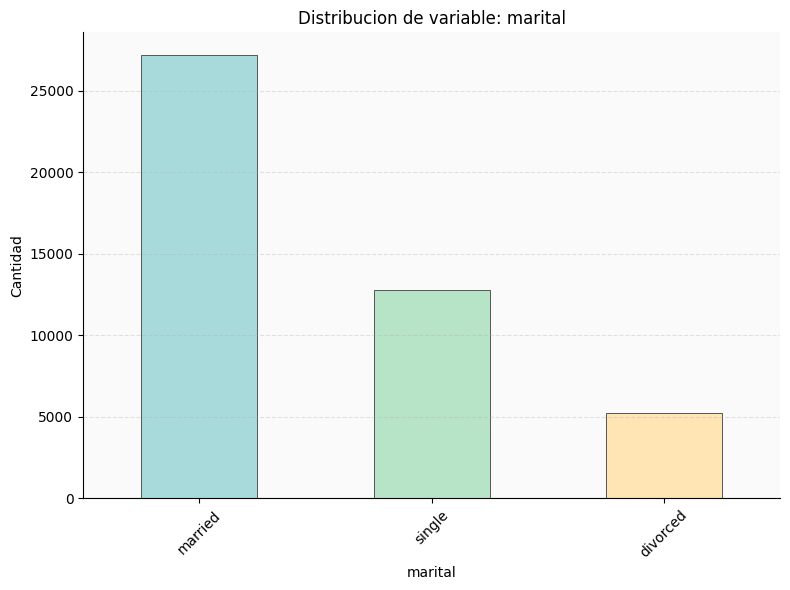

In [100]:
canMulti = df01.groupBy('marital').count().toPandas()
### se grafica en orden ascendente segun frecuencia
cantMulti= canMulti.sort_values('count', ascending=False)
plt.figure(figsize=(8,6))
coloresPasteles = ['#A8DADC', '#B7E4C7', '#FFE5B4']
cantMulti.plot(kind='bar', x='marital', y='count', legend=None, color=coloresPasteles[:len(cantMulti)], edgecolor='#555555', linewidth=0.7, ax=plt.gca())
plt.xlabel('marital')
plt.ylabel('Cantidad')
plt.title(f'Distribucion de variable: marital')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.35)
plt.gca().set_facecolor('#FAFAFA')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

#### Marital

- En la variable marital se observa que la categoría married es la más frecuente dentro del conjunto de datos, seguida por single y finalmente divorced. Esto indica que la mayoría de clientes registrados se encuentran casados.

- La diferencia entre categorías es marcada, por lo que marital puede aportar información útil al modelo, especialmente si el estado civil está relacionado con comportamientos financieros o decisiones de ahorro.

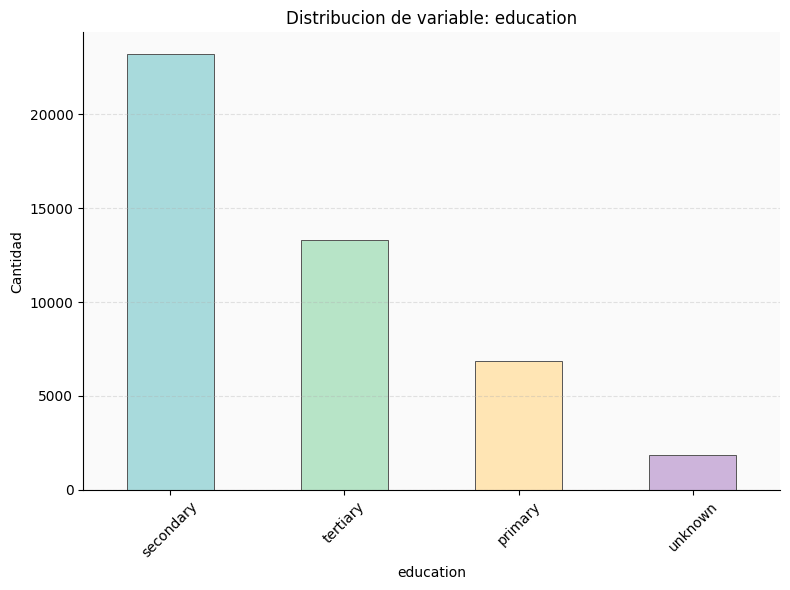

In [101]:
canMulti = df01.groupBy('education').count().toPandas()
### se grafica en orden ascendente segun frecuencia
cantMulti= canMulti.sort_values('count', ascending=False)
plt.figure(figsize=(8,6))
coloresPasteles = ['#A8DADC', '#B7E4C7', '#FFE5B4', '#CDB4DB']
cantMulti.plot(kind='bar', x='education', y='count', legend=None, color=coloresPasteles[:len(cantMulti)], edgecolor='#555555', linewidth=0.7, ax=plt.gca())
plt.xlabel('education')
plt.ylabel('Cantidad')
plt.title(f'Distribucion de variable: education')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.35)
plt.gca().set_facecolor('#FAFAFA')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

#### Education

- En la variable education se observa que la categoría secondary es la más frecuente, seguida por tertiary y primary. La categoría unknown tiene una cantidad mucho menor de registros.

- Esta distribución muestra que la mayoría de clientes tiene al menos educación secundaria, lo cual puede ser relevante para analizar diferencias en el comportamiento frente a la aceptación del depósito.

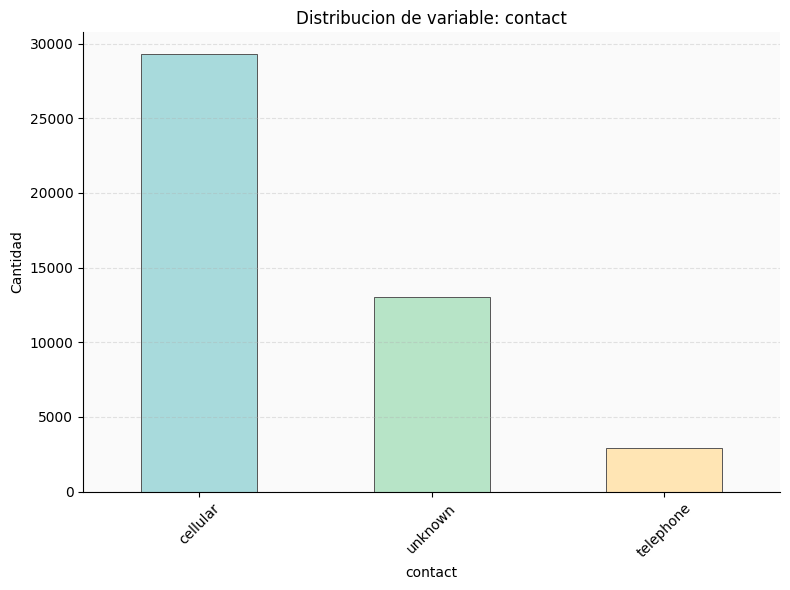

In [102]:
canMulti = df01.groupBy('contact').count().toPandas()
### se grafica en orden ascendente segun frecuencia
cantMulti= canMulti.sort_values('count', ascending=False)
plt.figure(figsize=(8,6))
coloresPasteles = ['#A8DADC', '#B7E4C7', '#FFE5B4']
cantMulti.plot(kind='bar', x='contact', y='count', legend=None, color=coloresPasteles[:len(cantMulti)], edgecolor='#555555', linewidth=0.7, ax=plt.gca())
plt.xlabel('contact')
plt.ylabel('Cantidad')
plt.title(f'Distribucion de variable: contact')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.35)
plt.gca().set_facecolor('#FAFAFA')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

#### Contact

- En la variable contact se evidencia que cellular es el medio de contacto más utilizado, con una diferencia clara frente a unknown y telephone.

- La categoría unknown todavía representa una cantidad importante de registros, por lo que puede afectar el análisis si no se interpreta correctamente. Esta variable puede ser relevante porque el canal de contacto puede influir en la efectividad de la campaña.


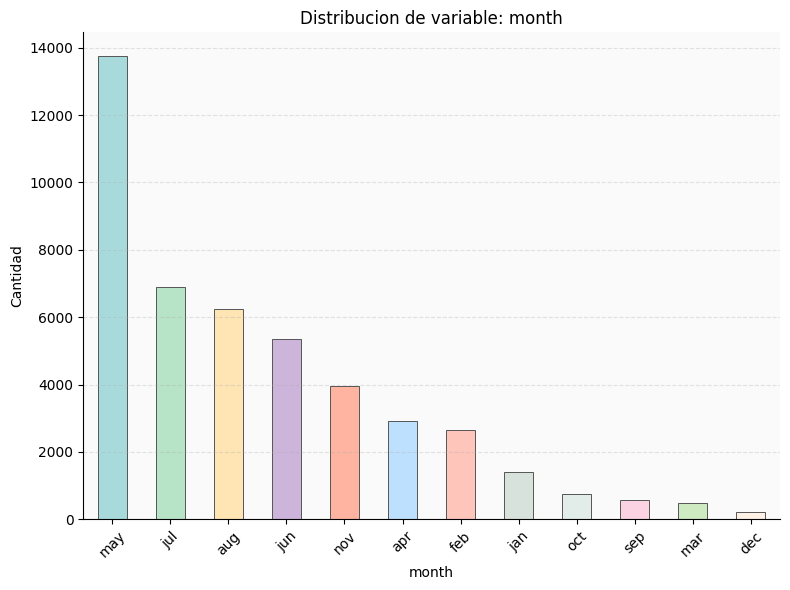

In [103]:
canMulti = df01.groupBy('month').count().toPandas()
### se grafica en orden ascendente segun frecuencia
cantMulti= canMulti.sort_values('count', ascending=False)
plt.figure(figsize=(8,6))
coloresPasteles = ['#A8DADC', '#B7E4C7', '#FFE5B4', '#CDB4DB', '#FFB4A2', '#BDE0FE', '#FEC5BB', '#D8E2DC', '#E2ECE9', '#FAD2E1', '#CDEAC0', '#FFF1E6']
cantMulti.plot(kind='bar', x='month', y='count', legend=None, color=coloresPasteles[:len(cantMulti)], edgecolor='#555555', linewidth=0.7, ax=plt.gca())
plt.xlabel('month')
plt.ylabel('Cantidad')
plt.title(f'Distribucion de variable: month')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.35)
plt.gca().set_facecolor('#FAFAFA')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

#### Month

- En la variable month se observa que mayo es el mes con mayor cantidad de contactos, seguido por julio, agosto y junio. Esto indica que la campaña no se distribuyó uniformemente durante todos los meses.

- Los meses con menor frecuencia, como diciembre, marzo y septiembre, tienen una participación mucho más baja. Esto puede influir en el modelo, ya que ciertos meses podrían estar asociados con mayor o menor respuesta de los clientes.


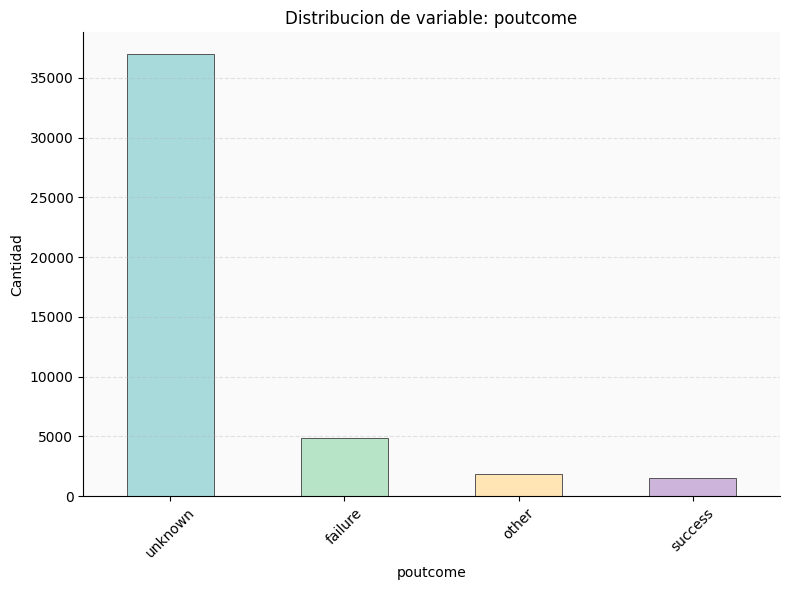

In [104]:
canMulti = df01.groupBy('poutcome').count().toPandas()
### se grafica en orden ascendente segun frecuencia
cantMulti= canMulti.sort_values('count', ascending=False)
plt.figure(figsize=(8,6))
coloresPasteles = ['#A8DADC', '#B7E4C7', '#FFE5B4', '#CDB4DB']
cantMulti.plot( kind='bar', x='poutcome', y='count', legend=None, color=coloresPasteles[:len(cantMulti)], edgecolor='#555555', linewidth=0.7, ax=plt.gca())
plt.xlabel('poutcome')
plt.ylabel('Cantidad')
plt.title(f'Distribucion de variable: poutcome')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.35)
plt.gca().set_facecolor('#FAFAFA')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

#### Poutcome

- En la variable poutcome se observa que la categoría unknown domina claramente la distribución, lo que indica que para la mayoría de clientes no se tiene información clara sobre el resultado de campañas anteriores.

- Las categorías failure, other y success tienen frecuencias mucho menores. Aun así, success puede ser una categoría importante, ya que podría indicar clientes con antecedentes positivos frente a campañas previas.


## Graficos de barras agrupados por variables categoricas en relacion a la variable dependiente "y" (deposito a plazo fijo)

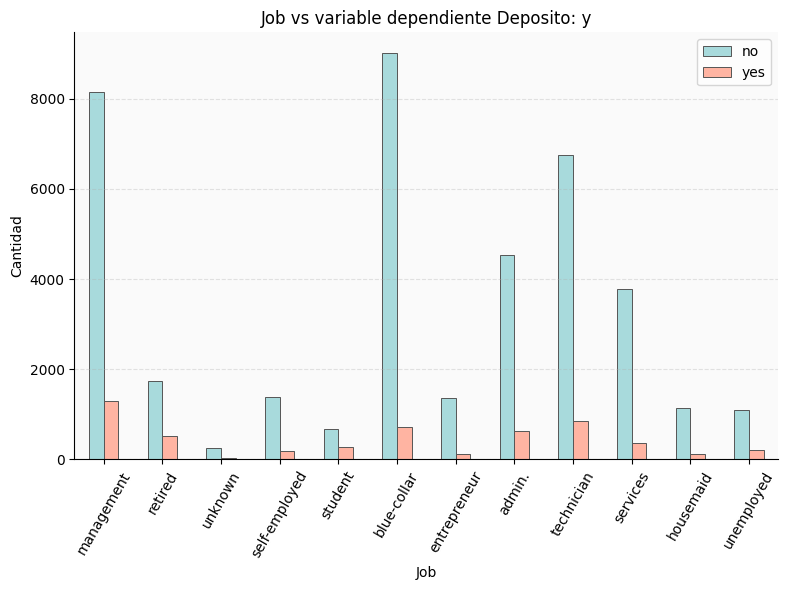

In [105]:
### Seleccionar solo las variables categoricas
### job, marital, education, default, housing, loan, contact, month, poutcome, y
cratabjob = df01.crosstab('job', 'y').toPandas()
coloresPasteles = ['#A8DADC', '#FFB4A2']
cratabjob.set_index('job' + '_y').plot(kind='bar', color=coloresPasteles, edgecolor='#555555', linewidth=0.7, figsize=(8,6))
plt.xlabel('Job')
plt.ylabel('Cantidad')
plt.title('Job vs variable dependiente Deposito: y')
plt.xticks(rotation=60)
plt.grid(axis='y', linestyle='--', alpha=0.35)
plt.gca().set_facecolor('#FAFAFA')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

#### Job vs variable dependiente Depósito: y

- En la gráfica de job frente a la variable y se observa que en casi todas las ocupaciones la categoría no supera ampliamente a yes. Esto indica que, en general, la mayoría de clientes no aceptó el depósito, independientemente del tipo de trabajo.

- Algunas ocupaciones como management, blue-collar y technician concentran una mayor cantidad de registros, por lo que pueden tener más peso dentro del entrenamiento del modelo. Sin embargo, la diferencia entre no y yes sigue siendo considerable, lo que confirma el desbalance de la variable objetivo.

In [29]:
df01.columns

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'y']

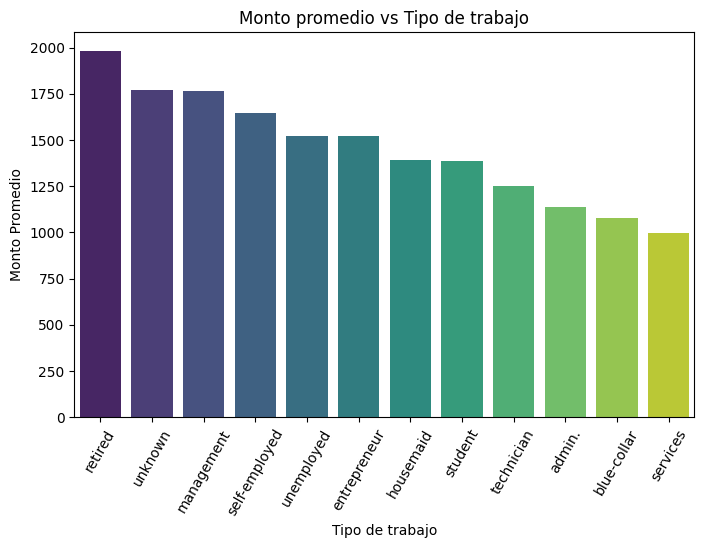

In [30]:
### Lista personal sobre el nombre de las variables
nomColumnas = ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'potcome', 'y']
###Las siguientes columnas son numericas
colNum = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

### Se requiere graficar la relacion del balance (monto pomedio anual) por categoria de Job (tipo de trabajo)
monto_trabajo = df01.groupBy('job').agg({'balance':'mean'}).toPandas()
### El promedio sobre el monto y el tipo de tabajo: se ordena de mayor a menor por monto
monto_trabajo = monto_trabajo.sort_values('avg(balance)', ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(data=monto_trabajo, x='job', y='avg(balance)', palette='viridis', hue='job')
plt.xlabel("Tipo de trabajo")
plt.ylabel("Monto Promedio")
plt.title("Monto promedio vs Tipo de trabajo")
plt.xticks(rotation=60)
plt.show()

               

#### Monto promedio vs Tipo de trabajo

- En la gráfica se observa que la categoría retired presenta el monto promedio más alto, seguida por unknown, management y self-employed. Esto indica que algunos perfiles laborales tienden a mostrar saldos promedio superiores dentro del conjunto de datos.

- Las categorías blue-collar y services aparecen entre los valores más bajos de monto promedio. Esto sugiere que el tipo de trabajo puede estar relacionado con diferencias en el balance económico de los clientes.

- La distribución no es uniforme entre ocupaciones, por lo que la variable job puede aportar información relevante al modelo, especialmente al combinarse con variables como balance, age y y.

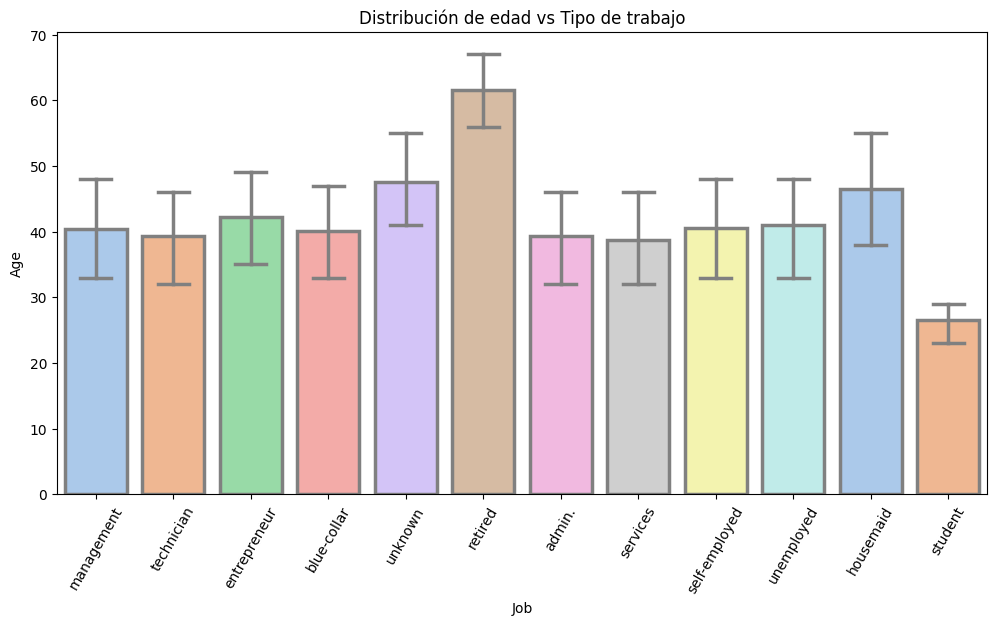

In [31]:
edad_trabajo = df01.select('age', 'job').toPandas()
plt.figure(figsize=(12,6))
sns.barplot(data=edad_trabajo,x='job',y='age',errorbar=("pi", 50), capsize=.4,err_kws={"color": ".5", "linewidth": 2.5},linewidth=2.5, edgecolor=".5", palette='pastel', hue='job')
plt.xlabel("Job")
plt.ylabel("Age")
plt.title("Distribución de edad vs Tipo de trabajo")
plt.xticks(rotation=60)
plt.show()

#### Distribución de edad vs Tipo de trabajo

- En la gráfica se observa que retired tiene la edad promedio más alta, lo cual es coherente con el significado de esta categoría laboral. Por otro lado, student presenta la edad promedio más baja, lo cual también es esperado.

- Las categorías management, technician, entrepreneur, blue-collar, admin., services, self-employed y unemployed se concentran principalmente entre edades medias, aproximadamente entre los 35 y 45 años.

- Las barras de error muestran que algunas categorías tienen mayor variabilidad en la edad, como retired, housemaid y unknown. Esto indica que dentro de ciertos grupos laborales existe una mayor dispersión en las edades de los clientes.

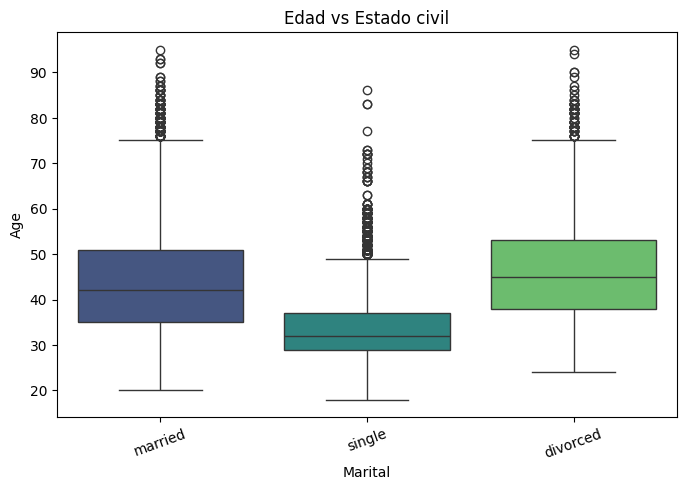

In [32]:
### Se requiere graficar la relacion de la edad por estado civil
edad_estado = df01.select('age', 'marital').toPandas()
plt.figure(figsize=(8,5))
sns.boxplot(data=edad_estado,x='marital',y='age',palette='viridis',hue='marital')
plt.xlabel("Marital")
plt.ylabel("Age")
plt.title("Edad vs Estado civil")
plt.xticks(rotation=20)
plt.show()

#### Edad vs Estado civil

- En la gráfica se observa que la categoría single tiene una mediana de edad menor frente a married y divorced. Esto indica que los clientes solteros tienden a concentrarse en edades más jóvenes dentro del conjunto de datos.

- La categoría divorced presenta una mediana de edad más alta y una distribución más amplia, lo que sugiere una mayor presencia de clientes adultos en este grupo. Por su parte, married también muestra una concentración importante en edades medias.

- Se observan valores atípicos en las tres categorías, especialmente en edades superiores a los 70 años. Esto indica que existen clientes de mayor edad en todos los estados civiles, aunque representan una proporción menor.


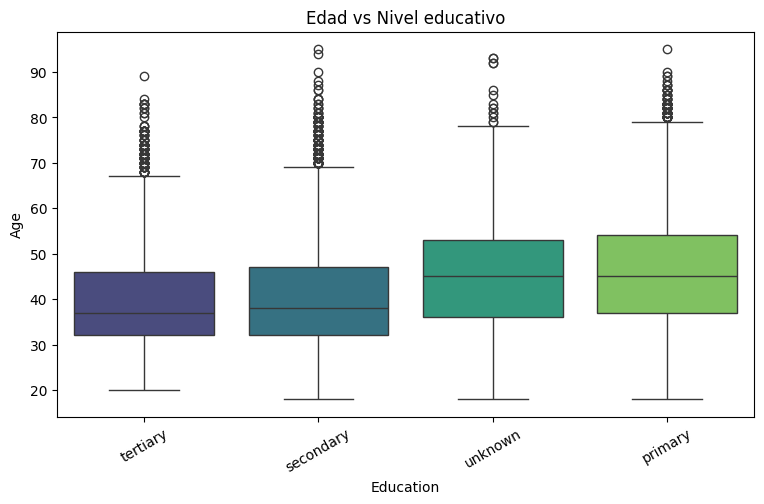

In [33]:
### Se requiere graficar la relacion de la edad por nivel educativo
edad_educacion = df01.select('age', 'education').toPandas()
plt.figure(figsize=(9,5))
sns.boxplot(data=edad_educacion,x='education',y='age',palette='viridis',hue='education')
plt.xlabel("Education")
plt.ylabel("Age")
plt.title("Edad vs Nivel educativo")
plt.xticks(rotation=30)
plt.show()

#### Edad vs Nivel educativo

- En la gráfica se observa que las categorías primary y unknown presentan medianas de edad más altas en comparación con tertiary y secondary. Esto puede indicar que los clientes con menor nivel educativo registrado tienden a pertenecer a grupos de mayor edad.

- Las categorías tertiary y secondary concentran clientes más jóvenes en promedio, con medianas cercanas entre sí. Esto muestra que los niveles educativos más frecuentes tienen una distribución de edad relativamente parecida.

- También se observan valores atípicos altos en todos los niveles educativos, especialmente en edades superiores a los 70 años. Esto indica que la edad varía ampliamente dentro de cada grupo educativo, aunque la mayor parte de los clientes se concentra entre los 30 y 50 años.

## 3. Calidad de los datos
-verificamos cantidad de datos nulos

In [34]:
for columna in df01.columns:
    cantNulos= df01.where(F.col(columna).isNull()).count()
    print(f"'{columna}' : {cantNulos} valores nulos")

'age' : 0 valores nulos
'job' : 0 valores nulos
'marital' : 0 valores nulos
'education' : 0 valores nulos
'default' : 0 valores nulos
'balance' : 0 valores nulos
'housing' : 0 valores nulos
'loan' : 0 valores nulos
'contact' : 0 valores nulos
'day' : 0 valores nulos
'month' : 0 valores nulos
'duration' : 0 valores nulos
'campaign' : 0 valores nulos
'pdays' : 0 valores nulos
'previous' : 0 valores nulos
'poutcome' : 0 valores nulos
'y' : 0 valores nulos


## 5.Preparacion de los datos
- Pdays
- Previous

In [35]:
### cantidad de duas que han pasado desde que el cliente fue contactado
## Se requiere saber la cantidad de -1 pdays (cliente no fue previamente contactado)
noPDAYS = df01.filter(F.col('pdays')== -1).count()
#Porcentaje
porcNoPDAYS = (noPDAYS/total)*100
print(f"Porcentaje de clientes no contactados con anterioridad (Variable PDAYS = -1): {porcNoPDAYS:.2f}%")

Porcentaje de clientes no contactados con anterioridad (Variable PDAYS = -1): 81.74%


## Comentarios:
- Porcentaje de Pdays es muy alto
- La correlacuon con previous es de 0.45 (fuerte)
- Se recomienda descartar la variable por el 82% de frecuencia y la alta relacion con la variable Previous
- Para la preparacion del actual investigacion se descarta la variable PDAYS

In [36]:
### La idea es revisar el valor limite de numero de contactos realizado por clientes

## Se presenta la cantidad de contactos realizados en orden descendiente
df01.groupBy("previous").count().sort("previous", ascending=False).show()

+--------+-----+
|previous|count|
+--------+-----+
|     275|    1|
|      58|    1|
|      55|    1|
|      51|    1|
|      41|    1|
|      40|    1|
|      38|    2|
|      37|    2|
|      35|    1|
|      32|    1|
|      30|    3|
|      29|    4|
|      28|    2|
|      27|    5|
|      26|    2|
|      25|    4|
|      24|    5|
|      23|    8|
|      22|    6|
|      21|    4|
+--------+-----+
only showing top 20 rows



## Comentarios: 
- En la tabla se observa que existen valores muy altos en la variable previous, llegando hasta 275 contactos previos. Sin embargo, estos casos tienen frecuencias muy bajas, generalmente de 1 a 8 registros, por lo que pueden considerarse valores atípicos dentro del conjunto de datos.

- La mayor parte de los registros con valores altos de previous aparece en cantidades muy pequeñas, lo que indica que no representan el comportamiento general de los clientes. Por esta razón, mantenerlos podría afectar el análisis y distorsionar el entrenamiento de los modelos.

- Al definir un límite máximo de 30 contactos previos, se identifican solo 12 registros superiores a este valor. Esto confirma que son casos aislados y que eliminarlos es una decisión razonable para reducir ruido en los datos y mejorar la calidad del modelo.

In [37]:
## Se toma como valor maximo 30 contactos por cliente y los demas atipicos
limitePrevio =30
## Canridad de registros con contactos "previous" superiores al limite
cantPrevioLim = df01.filter(F.col('previous')> limitePrevio).count()
print(f"Cantidad de registros superiores a {limitePrevio} contactos realizados: {cantPrevioLim}")

Cantidad de registros superiores a 30 contactos realizados: 12


## Analisis:
- Tras analizar los datos, se observa que, de los que tienen mas de 30 contactos solo con 12 clientes, lo que supone un caso atipico.
- Se recomienda eliminar los 12 registros


# 6.Limpieza de datos

In [38]:
## Se liminan los datos de "previous" con mas de 30 contactos
df02 = df01.filter(F.col('previous')<=30)

In [39]:
## Se elimina la columna "PDAYS"
df03 = df02.drop('pdays')

# 7.Formato de Datos
- Balanceo de aparicion de la variable dependiente de los datos
    - La idea es evitar el skew para la clase de mayor aparicion ("no")

In [40]:
## Balanceo de variable dependiente
dfMayorDependiente =df03.filter(df03['y'] == 'no')
dfMenorDependiente =df03.filter(df03['y'] == 'yes')

## Cantidad de clase mayoritaria (y)
cantMayor = dfMayorDependiente.count()

## Se realiza el oversampling sobre lla clase minoritaria de la variable dependiente
dfOverSampledMinor = dfMenorDependiente.sample(True, cantMayor/dfMenorDependiente.count(), seed=42)

## Se combina los dataframes balanceados
df04 = dfMayorDependiente.union(dfOverSampledMinor)

In [41]:
df04.columns

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'previous',
 'poutcome',
 'y']

In [42]:
## Se presenta el porcentaje segun balanceo aplicado
totalNw= df04.count()
dfaux = df04.groupBy('y').count()
dfBalance = dfaux.withColumn("Porcentaje", dfaux["count"]*100/totalNw)
dfBalance.show()

+---+-----+------------------+
|  y|count|        Porcentaje|
+---+-----+------------------+
| no|39912|50.077163398200774|
|yes|39789|49.922836601799226|
+---+-----+------------------+



In [43]:
print(f"Cantidad de registros de DF04= {df04.count()}")

Cantidad de registros de DF04= 79701


# 8. Codificacion de caracteristicas y creacion de vector
- oneHotEncodign para variables categoricas

In [44]:
## Columnas categoricas
CATEG_col = ['job', 'marital', 'education', 'default', 'month', 'housing', 'loan', 'contact', 'poutcome']
#vector de pipeline
etapas = []
for colCategorie in CATEG_col:
    #Se identifica el nombre de la categoria segun aparicion
    indexer = StringIndexer(inputCol=colCategorie, outputCol=colCategorie + 'x')
    #Se decodifica el indice de la cateforia
    encoder= OneHotEncoder(inputCols=[indexer.getOutputCol()], outputCols=[colCategorie + '_oneHot'])
    etapas += [indexer, encoder]

In [45]:
etapas

[StringIndexer_1e553deae030,
 OneHotEncoder_b75bf97f524d,
 StringIndexer_e71f88527698,
 OneHotEncoder_6ca1836b32ab,
 StringIndexer_663403c9b027,
 OneHotEncoder_ac24fd742414,
 StringIndexer_81f9f12c452e,
 OneHotEncoder_b9320535c0b3,
 StringIndexer_bad4c5770e14,
 OneHotEncoder_536647c9e803,
 StringIndexer_49ab27225836,
 OneHotEncoder_53d3ac8247cf,
 StringIndexer_0d2499347133,
 OneHotEncoder_a86cfad977d8,
 StringIndexer_8f3c7d6540a5,
 OneHotEncoder_3f8481fddee7,
 StringIndexer_f8dc697bad49,
 OneHotEncoder_18f208e522de]

In [46]:
## Creacion del StringIndexer con el orden deseado
#Al utilizar el stringOrderType = "alphabet", se indica que se asigne el indice de 0 a <<no>> y el indice 1 a <<yes>> segun el orden alfabetico
etiqueta = StringIndexer(inputCol='y', outputCol='label', stringOrderType='alphabetAsc')
etapas += [etiqueta]

In [47]:
# Caracteristicas numericsa
NUMER_col = ['age', 'balance', 'duration', 'day', 'campaign', 'previous']
entradaEnsamblada = [c + '_oneHot' for c in CATEG_col] + NUMER_col
entradaEnsamblada

['job_oneHot',
 'marital_oneHot',
 'education_oneHot',
 'default_oneHot',
 'month_oneHot',
 'housing_oneHot',
 'loan_oneHot',
 'contact_oneHot',
 'poutcome_oneHot',
 'age',
 'balance',
 'duration',
 'day',
 'campaign',
 'previous']

In [48]:
## Tabla de caracteristicas del vector para entrenamiento de los modelos
VectorEnsamblado = VectorAssembler(inputCols=entradaEnsamblada, outputCol='features')
etapas += [VectorEnsamblado]

In [49]:
etapas

[StringIndexer_1e553deae030,
 OneHotEncoder_b75bf97f524d,
 StringIndexer_e71f88527698,
 OneHotEncoder_6ca1836b32ab,
 StringIndexer_663403c9b027,
 OneHotEncoder_ac24fd742414,
 StringIndexer_81f9f12c452e,
 OneHotEncoder_b9320535c0b3,
 StringIndexer_bad4c5770e14,
 OneHotEncoder_536647c9e803,
 StringIndexer_49ab27225836,
 OneHotEncoder_53d3ac8247cf,
 StringIndexer_0d2499347133,
 OneHotEncoder_a86cfad977d8,
 StringIndexer_8f3c7d6540a5,
 OneHotEncoder_3f8481fddee7,
 StringIndexer_f8dc697bad49,
 OneHotEncoder_18f208e522de,
 StringIndexer_9e91d7ac1088,
 VectorAssembler_f70e45c5842f]

In [50]:
### pipeline para streaming: ejecucion de la transformacion del oneHotEncoder a el vector ensamblado 'features'
from pyspark.ml import Pipeline
pipeline = Pipeline(stages=etapas)
pipelineModel = pipeline.fit(df04)
## Se almacena el pipeline para usar en el streamung o ingesta de datos
pipelineModel.write().overwrite().save(path='modeloPipeline')
modelo = pipelineModel.transform(df04)


In [51]:
modelo.printSchema()

root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)
 |-- jobx: double (nullable = false)
 |-- job_oneHot: vector (nullable = true)
 |-- maritalx: double (nullable = false)
 |-- marital_oneHot: vector (nullable = true)
 |-- educationx: double (nullable = false)
 |-- education_oneHot: vector (nullable = true)
 |-- defaultx: double (nullable = false)
 |-- default_oneHot: vector (nullable = true)
 |-- monthx: double (nullable = false)

In [52]:
modelo.show(5)

+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+--------+--------+---+----+--------------+--------+--------------+----------+----------------+--------+--------------+------+--------------+--------+--------------+-----+-------------+--------+--------------+---------+---------------+-----+--------------------+
|age|         job|marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|previous|poutcome|  y|jobx|    job_oneHot|maritalx|marital_oneHot|educationx|education_oneHot|defaultx|default_oneHot|monthx|  month_oneHot|housingx|housing_oneHot|loanx|  loan_oneHot|contactx|contact_oneHot|poutcomex|poutcome_oneHot|label|            features|
+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+--------+--------+---+----+--------------+--------+--------------+----------+----------------+--------+--------------+------+--------------+--------+--------------+-----+---

In [53]:
df05 = modelo.select("label", "features")

### se imprime el pimer registro para hacer inspeccion ocular
df05.first()

Row(label=0.0, features=SparseVector(41, {0: 1.0, 11: 1.0, 14: 1.0, 16: 1.0, 17: 1.0, 29: 1.0, 31: 1.0, 32: 1.0, 35: 58.0, 36: 2143.0, 37: 261.0, 38: 5.0, 39: 1.0}))

In [54]:
df05.printSchema()

root
 |-- label: double (nullable = false)
 |-- features: vector (nullable = true)



In [55]:
###parquet
df05.write.mode("overwrite").parquet("output.parquet")

In [56]:
#df06 = sparkEspinosa.read.parquet("output.parquet")
#df06.show(2)


In [57]:
df05.first()

Row(label=0.0, features=SparseVector(41, {0: 1.0, 11: 1.0, 14: 1.0, 16: 1.0, 17: 1.0, 29: 1.0, 31: 1.0, 32: 1.0, 35: 58.0, 36: 2143.0, 37: 261.0, 38: 5.0, 39: 1.0}))

In [58]:
df05.printSchema()

root
 |-- label: double (nullable = false)
 |-- features: vector (nullable = true)



## 9. Modelamiento




In [59]:
trainData, testData = df05.randomSplit([.8,.2], seed=4321)
# se revisa la cantidad de datos
print(f"Cantidad del conjunto de datos de entrenamiento: {trainData.count()}")
print(f"Cantidad del conjunto de datos de prueba: {testData.count()}")


Cantidad del conjunto de datos de entrenamiento: 63791


[Stage 353:==================================================>    (11 + 1) / 12]

Cantidad del conjunto de datos de prueba: 15910


In [60]:
## Se verifica el balanceo del conjunto de datos de entrenamiento
distroTrain = trainData.groupBy("label").count()
##Visualizacion de balanceo de porcentaje
distroTrain = distroTrain.withColumn("Porcentaje", distroTrain["count"]*100/trainData.count())
distroTrain.show()

[Stage 359:=============================================>         (10 + 2) / 12]

+-----+-----+-----------------+
|label|count|       Porcentaje|
+-----+-----+-----------------+
|  0.0|31902|50.01018952516813|
|  1.0|31889|49.98981047483187|
+-----+-----+-----------------+



In [61]:
## Se verifica el balanceo del conjunto de datos de prueba
distroTest = testData.groupBy("label").count()
##Visualizacion de balanceo de porcentaje
distroTest = distroTest.withColumn("Porcentaje", distroTest["count"]*100/testData.count())
distroTest.show()

[Stage 365:==================================================>    (11 + 1) / 12]

+-----+-----+------------------+
|label|count|        Porcentaje|
+-----+-----+------------------+
|  0.0| 8010|50.345694531741046|
|  1.0| 7900|49.654305468258954|
+-----+-----+------------------+



In [62]:
#Comentarios

In [63]:
## Funcion para la matriz de confusion: Grafica
def plotMatConfusion(confMatrix, subtitulo):
    #Dataframe a pandas
    confMatrixPandas = confMatrix.toPandas()
    #restructuracion para crear la matriz de confusion
    confMatrixPivote = confMatrixPandas.pivot(index='label', columns ='Prediction', values='count').fillna(0)
    #Se grafica la matriz de confusion
    plt.figure(figsize=(8, 6))
    sns.heatmap(confMatrixPivote, annot=True, fmt='g')
    plt.suptitle(subtitulo)
    plt.title('Matriz de confusion')
    plt.xlabel('Label prediccion')
    plt.ylabel('Label')
    plt.show()

In [64]:
## Funcion para la ROC
def plotROC(predictions, rocMetric, subtitulo):
    #Obtener las probabilidades previstas para la clase positiva
    probs = predictions.select('probability').rdd.map(lambda row: row['probability'][1])
    #obtener las etiquetas verdaderas
    labels = predictions.select('label').rdd.map(lambda row: row['label'])
    #calcular la curva Roc usando los datos de las probabilidades de etiquetas verdaderas
    fpr, tpr, thresholds = roc_curve(labels.collect(), probs.collect())
    ##Se grafica la curva ROC
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label='Roc curve (area= %0.2f)' %rocMetric)
    plt.plot([0, 1], [0,1], color = 'red', lw=2, linestyle='--')
    plt.xlabel('Proporcion de falsos positivos')
    plt.ylabel('Proporcion de verdaderos positivos')
    plt.title('Curva receiver operating charasteristics (ROC)')
    plt.suptitle(subtitulo)
    plt.legend(loc='lower right')
    plt.show()

# Primer modelo: [linear regression](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.regression.LinearRegression.html)
-creacuon del objeto entrendao modelo LR

In [65]:
from pyspark.ml.classification import LogisticRegression
instanciaLR = LogisticRegression(featuresCol='features', labelCol='label', maxIter=10)
##Entrenamiento del modelo conddatos de entrenamiento
modeloLR = instanciaLR.fit(trainData)

26/05/25 22:18:48 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
                                                                                

- **Predccion** sobre el objeto entrenado: modelo LR

In [66]:
## Prediccion sobre los datos de prueba
predLR = modeloLR.transform(testData)
# se presentan las 10 primeras predicciones del modelo LR
predLR.select("label", "prediction", "probability").show(5)

[Stage 392:>                                                        (0 + 1) / 1]

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.89508734554918...|
|  0.0|       0.0|[0.97067036205576...|
|  0.0|       0.0|[0.95546647554453...|
|  0.0|       0.0|[0.96629961409848...|
|  0.0|       0.0|[0.98408785044433...|
+-----+----------+--------------------+
only showing top 5 rows



In [67]:
evaluadorLR = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

## -Matrix de confusion: modelo LR

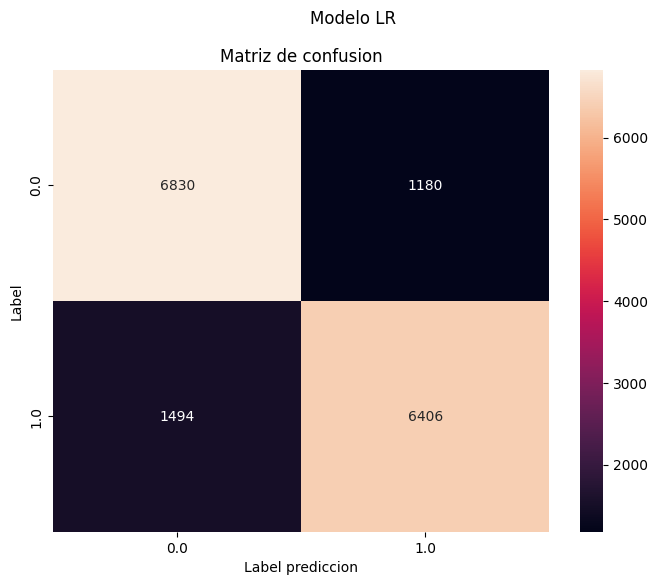

Resultados
precision: 0.832 %
Recall: 0.832 %
Accuracy: 0.832 %
f1Score: 0.832 %


In [68]:
# Se crea la matrix d econfusion: prediccion en datos de prueba con Modelo LR
primerModelo = "Modelo LR"
confMatrixLR = predLR.groupBy("label", "Prediction").count()
plotMatConfusion(confMatrixLR,primerModelo)

#Calculo de las metricas del modelo LR usando el evaluador Multiclase
accuracyLR = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: "accuracy"})
precisionLR = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: "weightedPrecision"})
recallLR = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: "weightedRecall"})
f1ScoreLR = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: "f1"})

# imoresion de las metricas
print(f"Resultados")
print(f"precision: {round(precisionLR,3)} %")
print(f"Recall: {round(recallLR,3)} %")
print(f"Accuracy: {round(accuracyLR,3)} %")
print(f"f1Score: {round(f1ScoreLR,3)} %")

0.9096279018315715
areaUnderROC


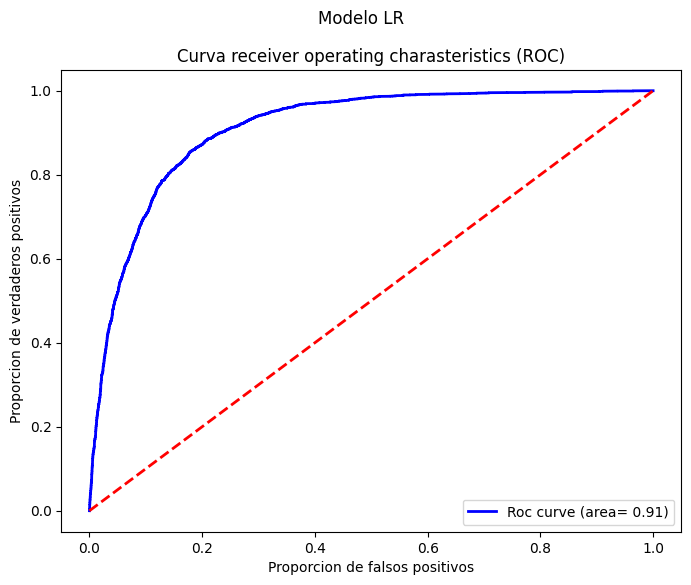

In [69]:
#Se crea un evaluador para metricas de clasificacion binaria (area sobre la curva ROC)
evaluadorBinLR = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")
#Se clacula y se presenta la grafica ROC con predicciones
rocLR = evaluadorBinLR.evaluate(predLR)
print(rocLR)
print(evaluadorBinLR.getMetricName())
plotROC(predLR, rocLR, primerModelo)

### Comentarios del Modelo LR:

- El Modelo LR presenta un rendimiento general sólido, con valores de Accuracy, Precision, Recall y F1-Score de 0.832. Esto indica que el modelo mantiene un comportamiento equilibrado entre aciertos generales, precisión en las predicciones y capacidad para identificar correctamente las clases.

- En la matriz de confusión se observa que el modelo clasifica correctamente una cantidad alta de registros en ambas clases: 6596 casos de la clase 0 y 6633 casos de la clase 1. Sin embargo, también presenta errores importantes, con 1241 casos de la clase 0 clasificados como clase 1 y 1438 casos de la clase 1 clasificados como clase 0.

- La curva ROC muestra un desempeño favorable, con un valor aproximado de 0.906. Esto indica que el modelo tiene una buena capacidad para separar las clases, por lo que funciona como una base fuerte de comparación frente a modelos más complejos.

## Segundo modelo: [Decision Tree](https://spark.apache.org/docs/latest/ml-classification-regression.html#decision-trees)
-  Creacion del modelo entrenado: modelo DT

In [70]:
from pyspark.ml.classification import DecisionTreeClassifier

instanciaDT = DecisionTreeClassifier(
    labelCol='label',
    featuresCol="features"
)

# Entrenamiento del modelo con Datos de Entrenamiento
modeloDT = instanciaDT.fit(trainData)

- Pediccion sobre el objeto entrenado: modelo DT

In [71]:
# Predicción sobre los datos de prueba
predDT = modeloDT.transform(testData)

# Se presentan las 10 primeras predicciones del modelo LR
predDT.select("label", "prediction", "probability").show(10)

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.91601278698052...|
|  0.0|       0.0|[0.85004182626689...|
|  0.0|       0.0|[0.85004182626689...|
|  0.0|       0.0|[0.91601278698052...|
|  0.0|       0.0|[0.85004182626689...|
|  0.0|       0.0|[0.91601278698052...|
|  0.0|       0.0|[0.85004182626689...|
|  0.0|       0.0|[0.85004182626689...|
|  0.0|       0.0|[0.91601278698052...|
|  0.0|       0.0|[0.91601278698052...|
+-----+----------+--------------------+
only showing top 10 rows



In [72]:
evaluadorDT = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

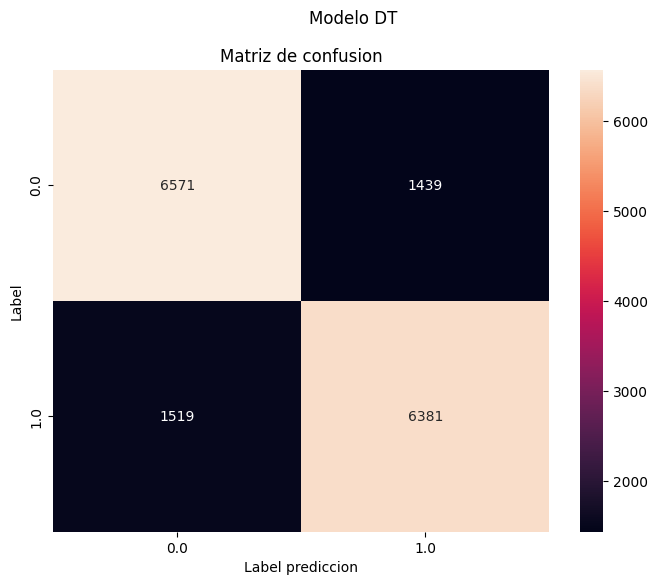

[Stage 441:==================================================>    (11 + 1) / 12]

Resultados
Precision: 0.814 %
Recall: 0.814 %
Accuracy: 0.814 %
f1Score: 0.814 %


In [73]:
# Se crea la matriz de confusion: prediccion en datos de prueba con Modelo DT
segundoModelo = "Modelo DT"
confMatrixDT = predDT.groupBy("label", "Prediction").count()
plotMatConfusion(confMatrixDT, segundoModelo)

# Calculo de las metricas del modelo DT usando el evaluador Multiclase
accuracyDT = evaluadorDT.evaluate(predDT, {evaluadorDT.metricName: "accuracy"})
precisionDT = evaluadorDT.evaluate(predDT, {evaluadorDT.metricName: "weightedPrecision"})
recallDT = evaluadorDT.evaluate(predDT, {evaluadorDT.metricName: "weightedRecall"})
f1ScoreDT = evaluadorDT.evaluate(predDT, {evaluadorDT.metricName: "f1"})

# Impresion de las metricas
print(f"Resultados")
print(f"Precision: {round(precisionDT,3)} %")
print(f"Recall: {round(recallDT,3)} %")
print(f"Accuracy: {round(accuracyDT,3)} %")
print(f"f1Score: {round(f1ScoreDT,3)} %")

0.6794683623318952
areaUnderROC


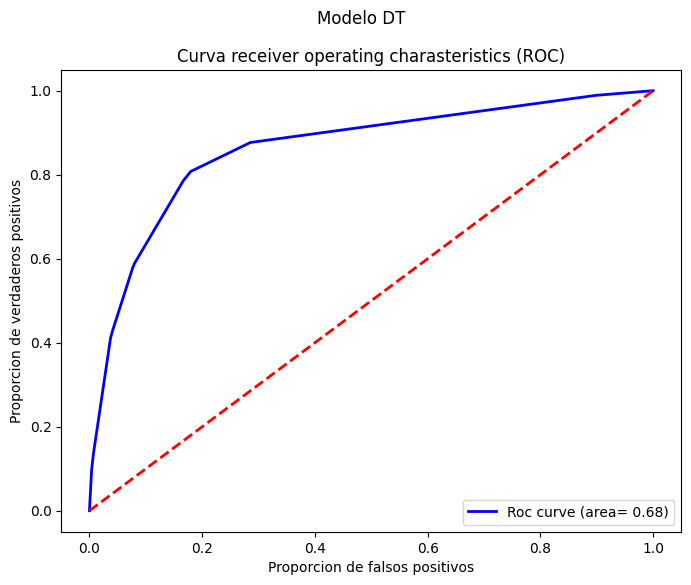

In [74]:
# Se crea un evaluador para metricas de clasificacion binaria
# (area sobre la curva ROC)
evaluadorBinDT = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")

# Se calcula y se presenta la grafica ROC con predicciones
rocDT = evaluadorBinDT.evaluate(predDT)

print(rocDT)
print(evaluadorBinDT.getMetricName())

plotROC(predDT, rocDT, segundoModelo)

### Comentarios del Modelo DT:

- El Modelo DT presenta un rendimiento general aceptable, con valores de Precision, Recall, Accuracy y F1-Score de 0.810. Esto indica que el modelo logra clasificar una buena parte de los registros, aunque su desempeño es menor en comparación con el Modelo LR.

- En la matriz de confusión se observa que el modelo clasifica correctamente 6292 casos de la clase 0 y 6599 casos de la clase 1. Sin embargo, presenta 1545 casos de la clase 0 clasificados como clase 1 y 1472 casos de la clase 1 clasificados como clase 0, lo que evidencia una cantidad de errores más alta que en el modelo anterior.

- La curva ROC tiene un valor aproximado de 0.678, lo cual muestra una capacidad limitada para separar correctamente las clases. Aunque el modelo Decision Tree es fácil de interpretar, su rendimiento no parece ser el más fuerte para este conjunto de datos.

## Tercer Modelo: [Logistic Regression](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.classification.LogisticRegression.html)
-  Creacion del modelo entrenado: modelo LogR

In [75]:
from pyspark.ml.classification import LogisticRegression
# Se crea el modelo Logistic Regression
instanciaLogR = LogisticRegression(featuresCol='features', labelCol='label', predictionCol="Prediction", maxIter=10)
##Entrenamiento del modelo con datos de entrenamiento
modeloLogR = instanciaLogR.fit(trainData)
## Prediccion sobre los datos de prueba
predLogR = modeloLogR.transform(testData)
# se presentan las 10 primeras predicciones del modelo Logistic Regression
predLogR.select("label", "Prediction", "probability").show(5)

+-----+----------+--------------------+
|label|Prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.89508734554918...|
|  0.0|       0.0|[0.97067036205576...|
|  0.0|       0.0|[0.95546647554453...|
|  0.0|       0.0|[0.96629961409848...|
|  0.0|       0.0|[0.98408785044433...|
+-----+----------+--------------------+
only showing top 5 rows



In [76]:
# Se crea el evaluador para las metricas del modelo Logistic Regression
evaluadorLogR = MulticlassClassificationEvaluator(labelCol="label", predictionCol="Prediction")

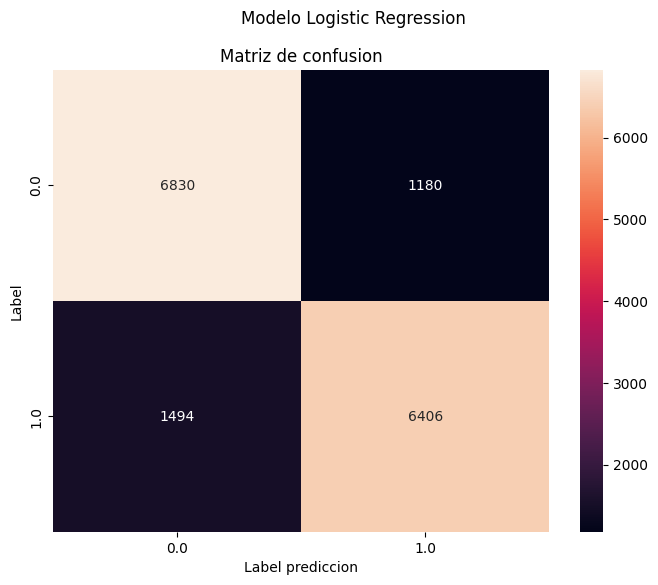

[Stage 490:==================================================>    (11 + 1) / 12]

Resultados
precision: 0.832 %
Recall: 0.832 %
Accuracy: 0.832 %
f1Score: 0.832 %


In [77]:
# Se crea la matrix de confusion: prediccion en datos de prueba con Modelo Logistic Regression
primerModelo = "Modelo Logistic Regression"
confMatrixLogR = predLogR.groupBy("label", "Prediction").count()
plotMatConfusion(confMatrixLogR, primerModelo)
#Calculo de las metricas del modelo Logistic Regression usando el evaluador Multiclase
accuracyLogR = evaluadorLogR.evaluate(predLogR, {evaluadorLogR.metricName: "accuracy"})
precisionLogR = evaluadorLogR.evaluate(predLogR, {evaluadorLogR.metricName: "weightedPrecision"})
recallLogR = evaluadorLogR.evaluate(predLogR, {evaluadorLogR.metricName: "weightedRecall"})
f1ScoreLogR = evaluadorLogR.evaluate(predLogR, {evaluadorLogR.metricName: "f1"})

# impresion de las metricas
print(f"Resultados")
print(f"precision: {round(precisionLogR,3)} %")
print(f"Recall: {round(recallLogR,3)} %")
print(f"Accuracy: {round(accuracyLogR,3)} %")
print(f"f1Score: {round(f1ScoreLogR,3)} %")

0.9096263768390777
areaUnderROC


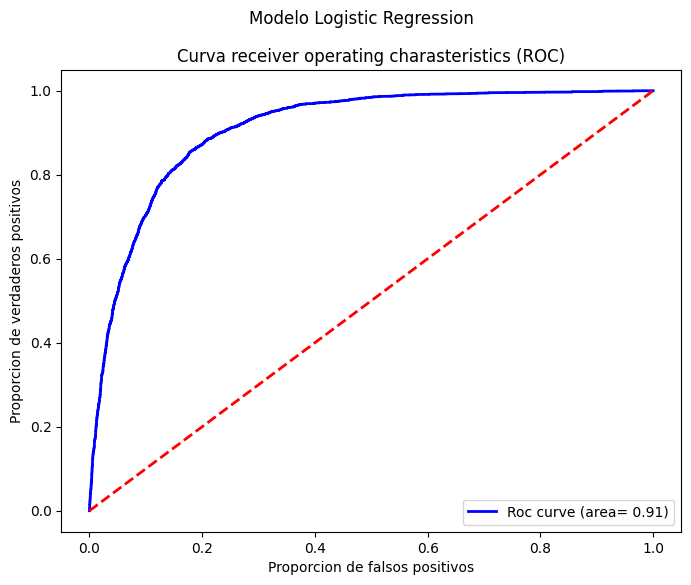

In [78]:
#Se crea un evaluador para metricas de clasificacion binaria (area sobre la curva ROC)
evaluadorBinLogR = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")

#Se calcula y se presenta la grafica ROC con predicciones
rocLogR = evaluadorBinLogR.evaluate(predLogR)

print(rocLogR)
print(evaluadorBinLogR.getMetricName())

plotROC(predLogR, rocLogR, primerModelo)

### Comentarios del Modelo Logistic Regression:

- El Modelo Logistic Regression presenta un rendimiento general sólido, con valores de Precision, Recall, Accuracy y F1-Score de 0.832. Esto indica que el modelo mantiene un comportamiento equilibrado y logra clasificar correctamente una proporción importante de los registros.

- En la matriz de confusión se observa que el modelo clasifica correctamente 6596 casos de la clase 0 y 6633 casos de la clase 1. Sin embargo, también presenta 1241 casos de la clase 0 clasificados como clase 1 y 1438 casos de la clase 1 clasificados como clase 0.

- La curva ROC muestra un valor aproximado de 0.906, lo cual indica una buena capacidad para separar las clases. Por lo tanto, este modelo tiene un desempeño fuerte y funciona como una referencia importante frente a los demás modelos de clasificación.

## Cuarto Modelo: [Ramdom Forest](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.mllib.tree.RandomForest.html)
-  Creacion del modelo entrenado: modelo RF

In [79]:
from pyspark.ml.classification import RandomForestClassifier

# Se crea el modelo Random Forest
instanciaRF = RandomForestClassifier( featuresCol='features', labelCol='label', predictionCol="Prediction", numTrees=50)
##Entrenamiento del modelo con datos de entrenamiento
modeloRF = instanciaRF.fit(trainData)
## Prediccion sobre los datos de prueba
predRF = modeloRF.transform(testData)
# se presentan las 10 primeras predicciones del modelo RF
predRF.select("label", "Prediction", "probability").show(5)

+-----+----------+--------------------+
|label|Prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.72481833242700...|
|  0.0|       0.0|[0.83407355726690...|
|  0.0|       0.0|[0.83045200484841...|
|  0.0|       0.0|[0.81348900137858...|
|  0.0|       0.0|[0.85452606557455...|
+-----+----------+--------------------+
only showing top 5 rows



In [80]:
# Se crea el evaluador para las metricas del modelo RF
evaluadorRF = MulticlassClassificationEvaluator( labelCol="label", predictionCol="Prediction")

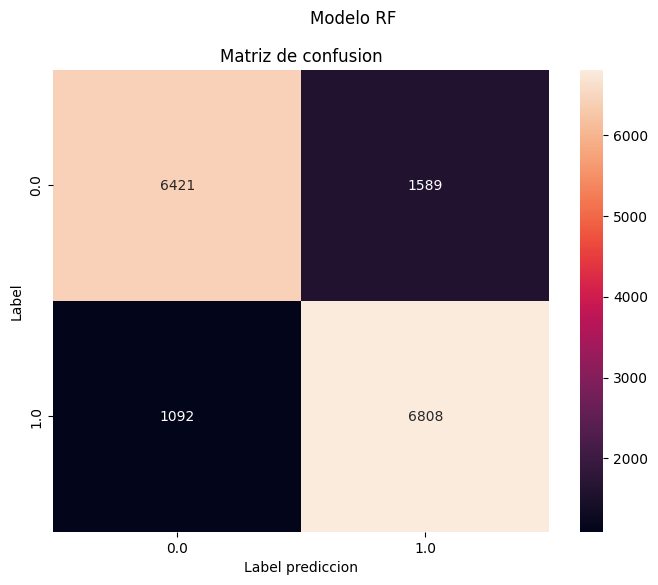

Resultados
precision: 0.833 %
Recall: 0.831 %
Accuracy: 0.831 %
f1Score: 0.831 %


In [81]:
# Se crea la matrix de confusion: prediccion en datos de prueba con Modelo RF
segundoModelo = "Modelo RF"
confMatrixRF = predRF.groupBy("label", "Prediction").count()
plotMatConfusion(confMatrixRF, segundoModelo)
#Calculo de las metricas del modelo RF usando el evaluador Multiclase
accuracyRF = evaluadorRF.evaluate(predRF, {evaluadorRF.metricName: "accuracy"})
precisionRF = evaluadorRF.evaluate(predRF, {evaluadorRF.metricName: "weightedPrecision"})
recallRF = evaluadorRF.evaluate(predRF, {evaluadorRF.metricName: "weightedRecall"})
f1ScoreRF = evaluadorRF.evaluate(predRF, {evaluadorRF.metricName: "f1"})

# impresion de las metricas
print(f"Resultados")
print(f"precision: {round(precisionRF,3)} %")
print(f"Recall: {round(recallRF,3)} %")
print(f"Accuracy: {round(accuracyRF,3)} %")
print(f"f1Score: {round(f1ScoreRF,3)} %")

0.9039787923323693
areaUnderROC


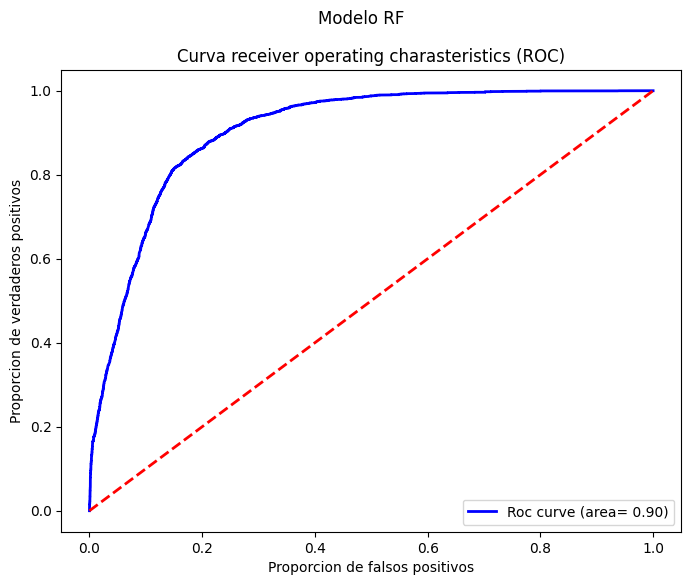

In [82]:
#Se crea un evaluador para metricas de clasificacion binaria (area sobre la curva ROC)
evaluadorBinRF = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")
#Se calcula y se presenta la grafica ROC con predicciones
rocRF = evaluadorBinRF.evaluate(predRF)
print(rocRF)
print(evaluadorBinRF.getMetricName())
plotROC(predRF, rocRF, segundoModelo)

### Comentarios del Modelo RF:

- El Modelo RF presenta un rendimiento general alto, con valores de Precision de 0.827, Recall de 0.825, Accuracy de 0.825 y F1-Score de 0.825. Esto indica que el modelo mantiene un desempeño estable y competitivo frente a los demás modelos evaluados.

- En la matriz de confusión se observa que el modelo clasifica correctamente 6141 casos de la clase 0 y 6984 casos de la clase 1. Sin embargo, también presenta 1696 casos de la clase 0 clasificados como clase 1 y 1087 casos de la clase 1 clasificados como clase 0.

- La curva ROC muestra un valor aproximado de 0.897, lo cual indica una buena capacidad para separar las clases. Aunque su desempeño es fuerte, queda ligeramente por debajo del Modelo LR y del Modelo Logistic Regression en la métrica ROC.

## Quinto Modelo: [Gradient Boosted Tree](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.mllib.tree.GradientBoostedTrees.html)
-  Creacion del modelo entrenado: modelo GBT

In [83]:
from pyspark.ml.classification import GBTClassifier

# Se crea el modelo Gradient Boosted Tree
instanciaGBT = GBTClassifier( featuresCol='features', labelCol='label', predictionCol="Prediction", maxIter=50)
##Entrenamiento del modelo con datos de entrenamiento
modeloGBT = instanciaGBT.fit(trainData)
## Prediccion sobre los datos de prueba
predGBT = modeloGBT.transform(testData)
# se presentan las 10 primeras predicciones del modelo GBT
predGBT.select("label", "Prediction").show(5)

+-----+----------+
|label|Prediction|
+-----+----------+
|  0.0|       0.0|
|  0.0|       0.0|
|  0.0|       0.0|
|  0.0|       0.0|
|  0.0|       0.0|
+-----+----------+
only showing top 5 rows



In [84]:
# Se crea el evaluador para las metricas del modelo GBT
evaluadorGBT = MulticlassClassificationEvaluator( labelCol="label", predictionCol="Prediction")

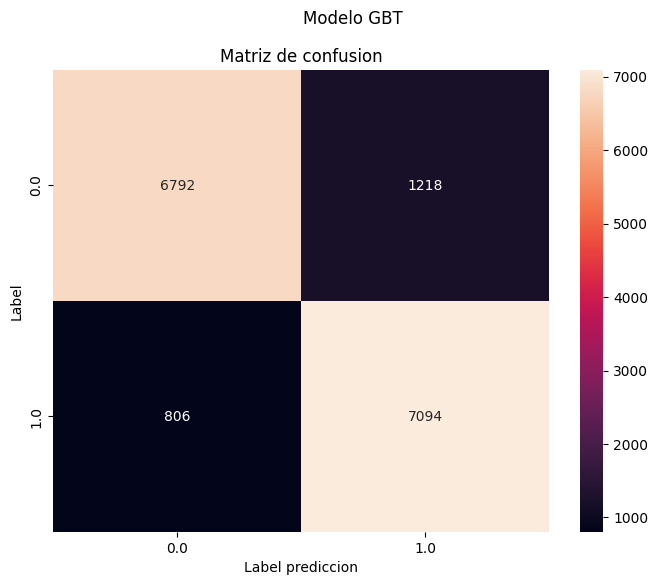

Resultados
precision: 0.874 %
Recall: 0.873 %
Accuracy: 0.873 %
f1Score: 0.873 %


In [85]:
# Se crea la matrix de confusion: prediccion en datos de prueba con Modelo GBT
tercerModelo = "Modelo GBT"
confMatrixGBT = predGBT.groupBy("label", "Prediction").count()
plotMatConfusion(confMatrixGBT, tercerModelo)
#Calculo de las metricas del modelo GBT usando el evaluador Multiclase
accuracyGBT = evaluadorGBT.evaluate(predGBT, {evaluadorGBT.metricName: "accuracy"})
precisionGBT = evaluadorGBT.evaluate(predGBT, {evaluadorGBT.metricName: "weightedPrecision"})
recallGBT = evaluadorGBT.evaluate(predGBT, {evaluadorGBT.metricName: "weightedRecall"})
f1ScoreGBT = evaluadorGBT.evaluate(predGBT, {evaluadorGBT.metricName: "f1"})

# impresion de las metricas
print(f"Resultados")
print(f"precision: {round(precisionGBT,3)} %")
print(f"Recall: {round(recallGBT,3)} %")
print(f"Accuracy: {round(accuracyGBT,3)} %")
print(f"f1Score: {round(f1ScoreGBT,3)} %")

0.9379584301268983
areaUnderROC


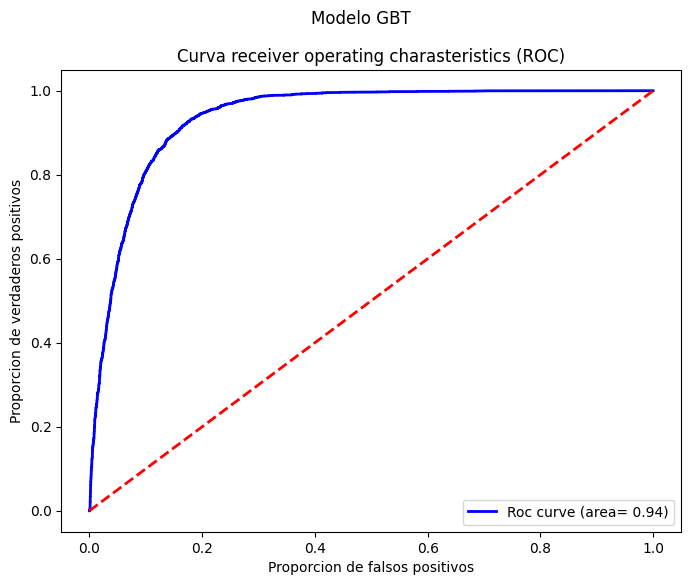

In [86]:
#Se crea un evaluador para metricas de clasificacion binaria (area sobre la curva ROC)
evaluadorBinGBT = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")
#Se calcula y se presenta la grafica ROC con predicciones
rocGBT = evaluadorBinGBT.evaluate(predGBT)
print(rocGBT)
print(evaluadorBinGBT.getMetricName())
plotROC(predGBT, rocGBT, tercerModelo)

### Comentarios del Modelo GBT:

- El Modelo GBT presenta el mejor rendimiento general hasta este punto, con valores de Precision de 0.875, Recall de 0.873, Accuracy de 0.873 y F1-Score de 0.873. Esto indica que el modelo logra un equilibrio alto entre precisión, capacidad de detección y clasificación correcta de los registros.

- En la matriz de confusión se observa que el modelo clasifica correctamente 6557 casos de la clase 0 y 7332 casos de la clase 1. Además, presenta 1280 casos de la clase 0 clasificados como clase 1 y 739 casos de la clase 1 clasificados como clase 0, mostrando una reducción importante de errores frente a modelos anteriores.

- La curva ROC alcanza un valor aproximado de 0.935, lo cual evidencia una capacidad muy alta para separar correctamente las clases. Por lo tanto, el Modelo GBT se posiciona como uno de los modelos más fuertes y recomendables dentro de la comparación.

## Sexto Modelo: [Support Vector Machine](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.mllib.classification.SVMModel.html)
-  Creacion del modelo entrenado: modelo SVM

In [87]:
from pyspark.ml.classification import LinearSVC

# Se crea el modelo Support Vector Machine
instanciaSVM = LinearSVC( featuresCol='features', labelCol='label', predictionCol="Prediction", maxIter=10, regParam=0.1)
##Entrenamiento del modelo con datos de entrenamiento
modeloSVM = instanciaSVM.fit(trainData)
## Prediccion sobre los datos de prueba
predSVM = modeloSVM.transform(testData)
# se presentan las 10 primeras predicciones del modelo SVM
predSVM.select("label", "Prediction").show(5)

+-----+----------+
|label|Prediction|
+-----+----------+
|  0.0|       0.0|
|  0.0|       0.0|
|  0.0|       0.0|
|  0.0|       0.0|
|  0.0|       0.0|
+-----+----------+
only showing top 5 rows



In [88]:
# Se crea el evaluador para las metricas del modelo SVM
evaluadorSVM = MulticlassClassificationEvaluator( labelCol="label", predictionCol="Prediction")

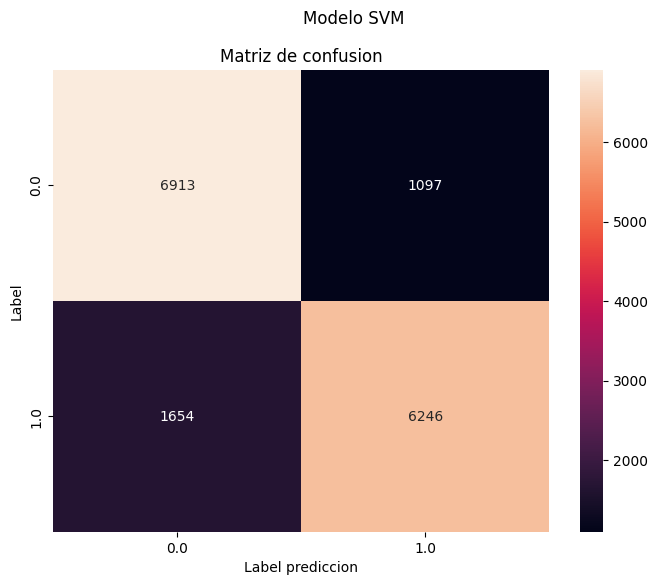

Resultados
precision: 0.829 %
Recall: 0.827 %
Accuracy: 0.827 %
f1Score: 0.827 %


In [89]:
# Se crea la matrix de confusion: prediccion en datos de prueba con Modelo SVM
cuartoModelo = "Modelo SVM"
confMatrixSVM = predSVM.groupBy("label", "Prediction").count()
plotMatConfusion(confMatrixSVM, cuartoModelo)
#Calculo de las metricas del modelo SVM usando el evaluador Multiclase
accuracySVM = evaluadorSVM.evaluate(predSVM, {evaluadorSVM.metricName: "accuracy"})
precisionSVM = evaluadorSVM.evaluate(predSVM, {evaluadorSVM.metricName: "weightedPrecision"})
recallSVM = evaluadorSVM.evaluate(predSVM, {evaluadorSVM.metricName: "weightedRecall"})
f1ScoreSVM = evaluadorSVM.evaluate(predSVM, {evaluadorSVM.metricName: "f1"})

# impresion de las metricas
print(f"Resultados")
print(f"precision: {round(precisionSVM,3)} %")
print(f"Recall: {round(recallSVM,3)} %")
print(f"Accuracy: {round(accuracySVM,3)} %")
print(f"f1Score: {round(f1ScoreSVM,3)} %")

In [90]:
# Funcion para graficar la curva ROC del modelo SVM
def plotROCSVM(predictions, rocMetric, subtitulo):
    # Obtener los valores de rawPrediction para la clase positiva
    probs = predictions.select('rawPrediction').rdd.map(lambda row: float(row['rawPrediction'][1]))
    # Obtener las etiquetas verdaderas
    labels = predictions.select('label').rdd.map(lambda row: row['label'])
    # Convertir los valores a listas
    probs = probs.collect()
    labels = labels.collect()
    # Calcular falsos positivos y verdaderos positivos
    frp, trp, thresholds = roc_curve(labels, probs)
    ##Se grafica la curva ROC
    plt.figure(figsize=(8, 6))
    plt.plot(frp, trp, color='blue', lw=2, label='Roc curve (area= %0.2f)' %rocMetric)
    plt.plot([0, 1], [0,1], color = 'red', lw=2, linestyle='--')
    plt.xlabel('Proporcion de falsos positivos')
    plt.ylabel('Proporcion de verdaderos positivos')
    plt.title('Curva ROC - ' + subtitulo)
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()

0.9077952638316035
areaUnderROC


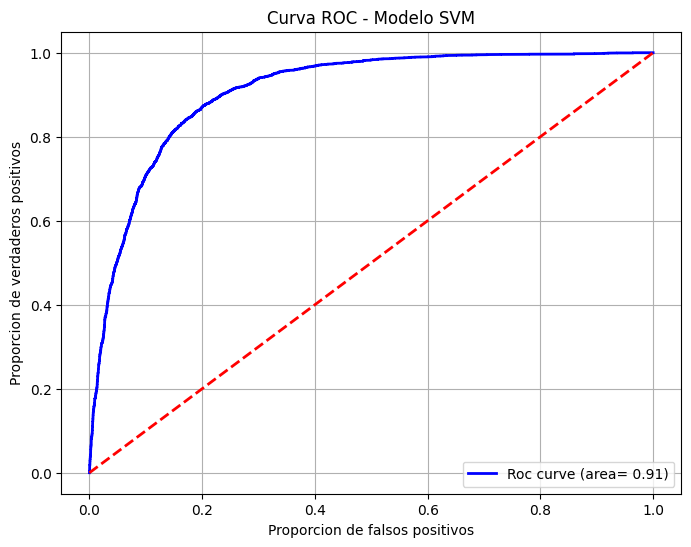

In [91]:
#Se crea un evaluador para metricas de clasificacion binaria (area sobre la curva ROC)
evaluadorBinSVM = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")

#Se calcula y se presenta la grafica ROC con predicciones
rocSVM = evaluadorBinSVM.evaluate(predSVM)

print(rocSVM)
print(evaluadorBinSVM.getMetricName())

plotROCSVM(predSVM, rocSVM, cuartoModelo)

### Comentarios del Modelo SVM:

- El Modelo SVM presenta un rendimiento general bueno, con valores de Precision de 0.830, Recall de 0.829, Accuracy de 0.829 y F1-Score de 0.829. Esto indica que el modelo mantiene un desempeño equilibrado y logra clasificar correctamente una proporción importante de los registros.

- En la matriz de confusión se observa que el modelo clasifica correctamente 6675 casos de la clase 0 y 6509 casos de la clase 1. Sin embargo, también presenta 1162 casos de la clase 0 clasificados como clase 1 y 1562 casos de la clase 1 clasificados como clase 0.

- La curva ROC muestra un valor aproximado de 0.908, lo cual indica una buena capacidad para separar las clases. Aunque el Modelo SVM tiene un desempeño competitivo, queda por debajo del Modelo GBT, que presenta mejores resultados generales y una curva ROC más alta.

## 10.Evaluacion de modelos

In [92]:
# Datos generales de los modelos
modelos = ['Regresión Lineal', 'Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosted Tree', 'Support Vector Machine']
accuracy = [accuracyLR, accuracyLogR, accuracyDT, accuracyRF, accuracyGBT, accuracySVM]
precision = [precisionLR, precisionLogR, precisionDT, precisionRF, precisionGBT, precisionSVM]
recall = [recallLR, recallLogR, recallDT, recallRF, recallGBT, recallSVM]
f1Score = [f1ScoreLR, f1ScoreLogR, f1ScoreDT, f1ScoreRF, f1ScoreGBT, f1ScoreSVM]
curvaROC = [rocLR, rocLogR, rocDT, rocRF, rocGBT, rocSVM]
# Se crea una tabla comparativa con las métricas de los modelos
resultadosModelos = [("Regresión Lineal", round(accuracyLR, 3), round(precisionLR, 3), round(recallLR, 3), round(f1ScoreLR, 3), round(rocLR, 3)), ("Logistic Regression", round(accuracyLogR, 3), round(precisionLogR, 3), round(recallLogR, 3), round(f1ScoreLogR, 3), round(rocLogR, 3)), ("Decision Tree", round(accuracyDT, 3), round(precisionDT, 3), round(recallDT, 3), round(f1ScoreDT, 3), round(rocDT, 3)), ("Random Forest", round(accuracyRF, 3), round(precisionRF, 3), round(recallRF, 3), round(f1ScoreRF, 3), round(rocRF, 3)), ("Gradient Boosted Tree", round(accuracyGBT, 3), round(precisionGBT, 3), round(recallGBT, 3), round(f1ScoreGBT, 3), round(rocGBT, 3)), ("Support Vector Machine", round(accuracySVM, 3), round(precisionSVM, 3), round(recallSVM, 3), round(f1ScoreSVM, 3), round(rocSVM, 3))]
columnasResultados = ["Modelo", "Accuracy", "Precision", "Recall", "F1-Score", "ROC"]
dfResultados = sparkEspinosa.createDataFrame(resultadosModelos, columnasResultados)

# Se presenta la tabla comparativa de resultados
dfResultados.show(truncate=False)

+----------------------+--------+---------+------+--------+-----+
|Modelo                |Accuracy|Precision|Recall|F1-Score|ROC  |
+----------------------+--------+---------+------+--------+-----+
|Regresión Lineal      |0.832   |0.832    |0.832 |0.832   |0.91 |
|Logistic Regression   |0.832   |0.832    |0.832 |0.832   |0.91 |
|Decision Tree         |0.814   |0.814    |0.814 |0.814   |0.679|
|Random Forest         |0.831   |0.833    |0.831 |0.831   |0.904|
|Gradient Boosted Tree |0.873   |0.874    |0.873 |0.873   |0.938|
|Support Vector Machine|0.827   |0.829    |0.827 |0.827   |0.908|
+----------------------+--------+---------+------+--------+-----+



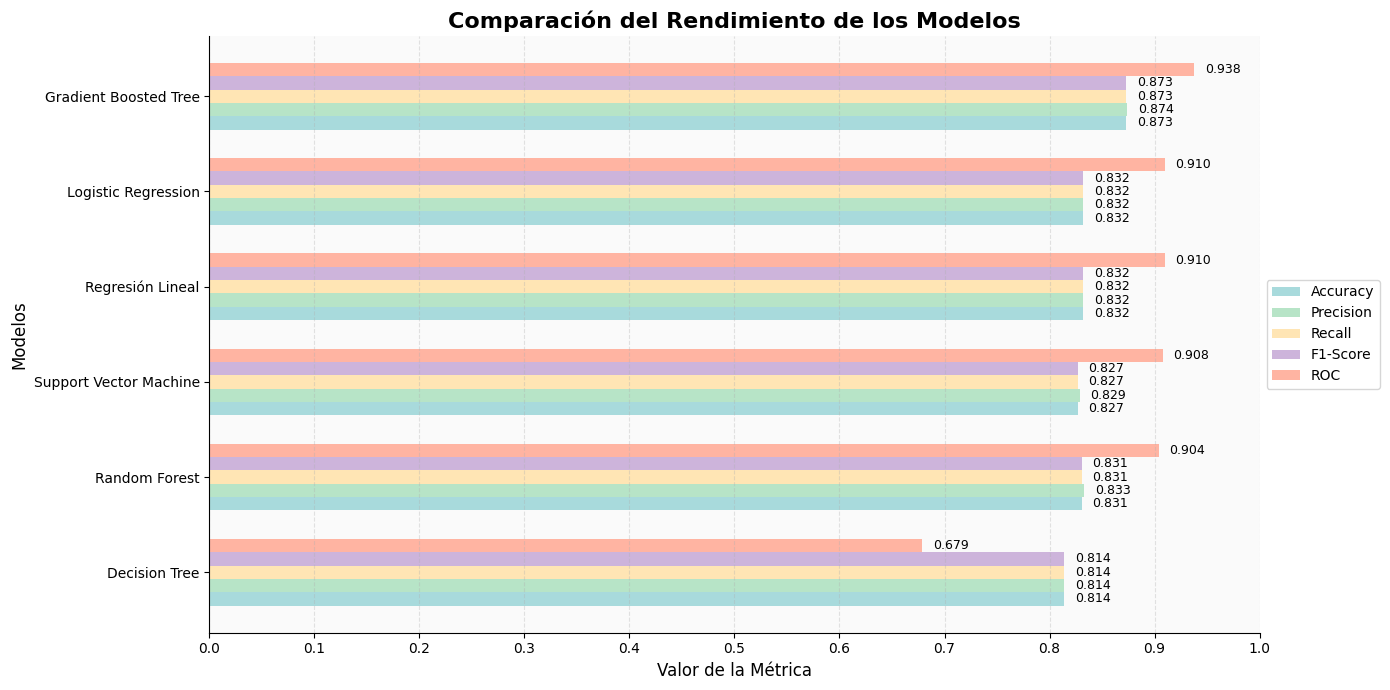

In [93]:
# Se convierte el DataFrame de Spark a Pandas para poder graficar
dfResultadosPandas = dfResultados.orderBy("ROC", ascending=True).toPandas()

# Se toman los valores ordenados desde la tabla
modelos = dfResultadosPandas['Modelo'].tolist()
accuracy = dfResultadosPandas['Accuracy'].tolist()
precision = dfResultadosPandas['Precision'].tolist()
recall = dfResultadosPandas['Recall'].tolist()
f1Score = dfResultadosPandas['F1-Score'].tolist()
curvaROC = dfResultadosPandas['ROC'].tolist()

longitud = 0.14
posHorizontal = np.arange(len(modelos))
plt.figure(figsize=(14, 7))
barra1 = plt.barh(posHorizontal - 0.28, accuracy, longitud, label='Accuracy', color='#A8DADC')
barra2 = plt.barh(posHorizontal - 0.14, precision, longitud, label='Precision', color='#B7E4C7')
barra3 = plt.barh(posHorizontal, recall, longitud, label='Recall', color='#FFE5B4')
barra4 = plt.barh(posHorizontal + 0.14, f1Score, longitud, label='F1-Score', color='#CDB4DB')
barra5 = plt.barh(posHorizontal + 0.28, curvaROC, longitud, label='ROC', color='#FFB4A2')
plt.ylabel('Modelos', fontsize=12)
plt.xlabel('Valor de la Métrica', fontsize=12)
plt.title('Comparación del Rendimiento de los Modelos', fontsize=16, fontweight='bold')
plt.yticks(posHorizontal, modelos)
plt.xticks(np.arange(0, 1.1, 0.1))
plt.grid(axis='x', linestyle='--', alpha=0.35)
plt.gca().set_facecolor('#FAFAFA')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

for barras in [barra1, barra2, barra3, barra4, barra5]:
    for barra in barras:
        ancho = barra.get_width()
        plt.text(ancho + 0.01, barra.get_y() + barra.get_height() / 2, f'{ancho:.3f}', va='center', fontsize=9)
plt.legend(handles=[barra1, barra2, barra3, barra4, barra5], loc='center left', bbox_to_anchor=(1, 0.5), labels=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC'], frameon=True)
plt.tight_layout()
plt.show()

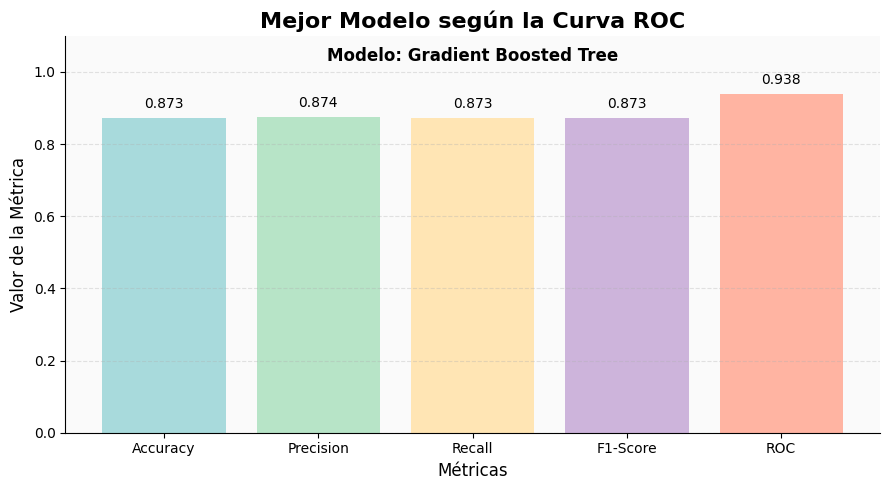

Mejor modelo según la curva ROC:
Modelo: Gradient Boosted Tree
ROC: 0.938
Accuracy: 0.873
Precision: 0.874
Recall: 0.873
F1-Score: 0.873


In [94]:
# Se identifica el mejor modelo según el valor de la curva ROC
mejorModelo = max(resultadosModelos, key=lambda x: x[5])
metricasMejorModelo = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC']
valoresMejorModelo = [mejorModelo[1], mejorModelo[2], mejorModelo[3], mejorModelo[4], mejorModelo[5]]
coloresPasteles = ['#A8DADC', '#B7E4C7', '#FFE5B4', '#CDB4DB', '#FFB4A2']
plt.figure(figsize=(9, 5))
barras = plt.bar(metricasMejorModelo, valoresMejorModelo, color=coloresPasteles)
plt.title('Mejor Modelo según la Curva ROC', fontsize=16, fontweight='bold')
plt.xlabel('Métricas', fontsize=12)
plt.ylabel('Valor de la Métrica', fontsize=12)
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.35)
plt.gca().set_facecolor('#FAFAFA')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width() / 2, altura + 0.02, f'{altura:.3f}', ha='center', va='bottom', fontsize=10)
plt.text(2, 1.03, f"Modelo: {mejorModelo[0]}", ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


print("Mejor modelo según la curva ROC:")
print(f"Modelo: {mejorModelo[0]}")
print(f"ROC: {mejorModelo[5]}")
print(f"Accuracy: {mejorModelo[1]}")
print(f"Precision: {mejorModelo[2]}")
print(f"Recall: {mejorModelo[3]}")
print(f"F1-Score: {mejorModelo[4]}")

### Comentarios:

- El modelo Gradient Boosted Tree presentó el mejor rendimiento general dentro de los modelos evaluados, especialmente al obtener el valor más alto en la curva ROC, lo cual indica una mayor capacidad para diferenciar correctamente entre las clases positivas y negativas.

- La métrica ROC fue utilizada como criterio principal de comparación, ya que permite evaluar qué tan bien cada modelo logra separar las clases del problema. En este caso, el modelo Gradient Boosted Tree obtuvo el mejor resultado en esta métrica, por encima de modelos como Regresión Lineal, Logistic Regression, Decision Tree, Random Forest y Support Vector Machine.

- La métrica más baja observada dentro de la comparación corresponde al modelo con menor desempeño en la evaluación general. Esto indica que, aunque algunos modelos pueden tener valores aceptables de Accuracy, no necesariamente presentan el mismo rendimiento al analizar métricas más completas como Recall, F1-Score o ROC.

- El modelo Regresión Lineal presenta una utilidad limitada para este tipo de problema, debido a que la variable dependiente corresponde a una tarea de clasificación. Aunque puede generar resultados comparables dentro del flujo de trabajo, no es el modelo más adecuado para este contexto frente a modelos diseñados específicamente para clasificación.

- El modelo Decision Tree permite una interpretación sencilla de los resultados, pero puede presentar menor capacidad predictiva frente a modelos más robustos como Random Forest o Gradient Boosted Tree. Esto se debe a que un solo árbol puede ser más sensible a la estructura específica de los datos.

- El modelo Random Forest mejora la estabilidad frente al Decision Tree, ya que utiliza varios árboles de decisión para reducir el riesgo de sobreajuste y mejorar la generalización. Sin embargo, en esta comparación no supera el desempeño del modelo Gradient Boosted Tree.

- El modelo Support Vector Machine también presenta un desempeño competitivo, pero su interpretación es menos directa y, además, no genera una columna de probabilidad como otros modelos, lo cual obliga a trabajar con `rawPrediction` para construir la curva ROC.

- Por lo tanto, el modelo sugerido para usar es Gradient Boosted Tree, debido a que presenta el mejor equilibrio entre capacidad predictiva, desempeño en la curva ROC y solidez frente a los demás modelos evaluados.

- En conclusión, para este conjunto de datos bancarios, el modelo Gradient Boosted Tree es la alternativa más recomendable para predecir si un cliente aceptará o no la campaña, ya que aprovecha mejor los patrones presentes en los datos y ofrece un rendimiento superior en comparación con los demás modelos implementados.

# 11. Conclusiones

- Durante el análisis exploratorio se pudo observar que el conjunto de datos presenta variables con comportamientos muy diferentes entre sí. Algunas variables numéricas como balance, duration, campaign, pdays y previous tienen distribuciones sesgadas y varios valores atípicos, lo cual indica que no todos los clientes se comportan de forma homogénea dentro de la campaña bancaria. Esto fue importante porque permitió entender que antes de entrenar los modelos era necesario revisar la calidad de los datos, identificar posibles valores extremos y preparar correctamente las variables para evitar que estos casos afectaran el rendimiento de los modelos.

- Una de las variables más importantes dentro del análisis fue duration, ya que mostró la relación más fuerte con la variable dependiente. En la matriz de correlación, duration obtuvo una correlación aproximada de 0.39 con y, siendo la variable numérica con mayor relación frente a la aceptación del depósito. Además, en los boxplots se observó que los clientes que aceptaron el depósito tendían a tener llamadas de mayor duración. Esto permite concluir que el tiempo de contacto tiene un papel relevante en la respuesta del cliente, ya que una llamada más larga puede indicar mayor interés, mejor interacción o más oportunidad para explicar la oferta.

- En la preparación de los datos se identificó que la variable pdays tenía un porcentaje muy alto de registros con valor -1, aproximadamente 81.74%, lo cual indica que la mayoría de clientes no había sido contactada previamente. Además, pdays tenía una relación considerable con previous, por lo que se decidió descartarla para evitar información poco útil o repetida dentro del modelo. También se revisó la variable previous y se encontraron valores atípicos muy altos, como clientes con más de 30 contactos previos. Como estos casos eran muy pocos, solo 12 registros, se eliminaron para reducir ruido y mejorar la calidad del conjunto de datos.

- Otro punto importante fue el balanceo de la variable dependiente. Al inicio, el conjunto de datos tenía una diferencia fuerte entre las clases yes y no, lo cual podía provocar que los modelos aprendieran más a predecir la clase mayoritaria. Después del balanceo, la distribución quedó prácticamente equilibrada, con 50.08% para no y 49.92% para yes. Esto fue una decisión adecuada porque permitió entrenar los modelos en condiciones más justas, evitando que una alta exactitud fuera producto únicamente del desbalance de clases.

- En el análisis de variables categóricas se observó que algunas categorías tienen una concentración muy marcada. Por ejemplo, en job predominan blue-collar, management y technician; en marital predomina married; en education predomina secondary; y en contact el medio más usado es cellular. También se observó que poutcome tiene una gran cantidad de valores unknown, lo cual indica que para muchos clientes no se conoce el resultado de campañas anteriores. Estas diferencias son importantes porque muestran que el comportamiento de los clientes no depende únicamente de variables numéricas, sino también de factores laborales, educativos, de contacto y de antecedentes de campañas.

- Al comparar los modelos implementados, se observó que Decision Tree fue el modelo con menor desempeño general, especialmente en la curva ROC, con un valor aproximado de 0.679. Aunque este modelo es fácil de interpretar, su capacidad para separar correctamente las clases fue menor frente a los demás modelos. Esto muestra que un solo árbol de decisión puede quedarse corto para capturar relaciones más complejas entre las variables del dataset.

- Los modelos Regresión Lineal, Logistic Regression, Random Forest y Support Vector Machine presentaron resultados competitivos, con valores de Accuracy, Precision, Recall y F1-Score cercanos entre sí. Sin embargo, aunque estos modelos tuvieron un rendimiento aceptable, no lograron superar al Gradient Boosted Tree. Esto indica que el problema necesita un modelo con mayor capacidad para capturar patrones combinados y relaciones no lineales entre las variables.

- El modelo Gradient Boosted Tree fue el que presentó el mejor rendimiento general. Obtuvo un Accuracy de 0.873, Precision de 0.874, Recall de 0.873, F1-Score de 0.873 y una curva ROC de 0.938. Estos resultados muestran que fue el modelo con mejor equilibrio entre clasificación correcta, precisión, capacidad de recuperación y separación entre clases. Además, en la matriz de confusión se evidenció una reducción importante de errores, especialmente en los casos de la clase 1 clasificados incorrectamente como clase 0.

- Por lo tanto, el modelo recomendado para este problema es Gradient Boosted Tree, ya que fue el que mejor explicó el comportamiento de la variable dependiente y presentó el desempeño más sólido en la evaluación final. Su ventaja principal es que combina varios árboles de forma secuencial, corrigiendo errores de modelos anteriores y logrando una mejor capacidad predictiva. Para este conjunto de datos bancarios, donde existen variables sesgadas, valores atípicos, relaciones no lineales y combinaciones importantes entre variables, este tipo de modelo resulta más adecuado que modelos más simples.

- En conclusión, el desarrollo completo del proyecto permitió pasar por todas las etapas necesarias de un proceso de clasificación: entendimiento de los datos, análisis exploratorio, limpieza, preparación, codificación de variables, balanceo, entrenamiento y evaluación de modelos. A partir de los resultados obtenidos, se puede afirmar que sí es posible construir un modelo capaz de predecir si un cliente aceptará o no un depósito bancario, y que el mejor enfoque encontrado fue usar Gradient Boosted Tree por su mayor rendimiento y mejor capacidad para diferenciar las clases de la variable dependiente.

In [107]:
sparkEspinosa.stop()